In [2]:
# import all the necessary libraries
import os
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from custom_functions import plot_comparison, plot_pp, plot_lissajous

In [149]:
# # The van der pol oscillator system (linear coupling)
# case = 'linear'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, alpha1=1.5, alpha2=1.5,epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] +  epsilon * (x[0]-x[2]),
#            x[3],
#            lambda2 * (1-x[2]**2) * x[3] - alpha2 * x[2] + epsilon * (x[2]-x[0])]

# # The van der pol oscillator system (combination of linear and quadratic coupling)
# case = 'linear+quadratic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, linear_coeff_1=0.3, linear_coeff_2=0.3, quadratic_coeff_1=0.1, quadratic_coeff_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + linear_coeff_1 * (x[0]-x[2]) +  quadratic_coeff_1 * (x[0]-x[2])**(2),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + linear_coeff_2 * (x[2]-x[0]) + quadratic_coeff_1 * (x[2]-x[0])**(2)]



# # The van der pol oscillator system (combination of linear, quadratic and cubic coupling)
# case = 'linear+quadratic+cubic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, cubic_coefficient_1=0.1, cubic_coefficient_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + cubic_coefficient_1*(x[0]-x[2])**(3),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + cubic_coefficient_2*(x[2]-x[0])**(3)]


# # The van der pol oscillator system (exponential coupling)
# case = 'exponential'
# x0 = [1, -1, -3.5, 0.5] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.6, lambda2=1.6, omega1=1.3, omega2=1.3, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (sinusoidal coupling)
# case = 'sinusoidal'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.5, lambda2=1.5, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])]

# The van der pol oscillator system (sinusoidal+exponential coupling)
# case = 'sinusoidal+exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2])*np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])*np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (plain exponential coupling)
# case = 'plain_exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(x[2]-x[0])]


In [150]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 0.1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

Iteration: 0
[-0.00844821  0.04610875 -0.02924662  0.03860327]


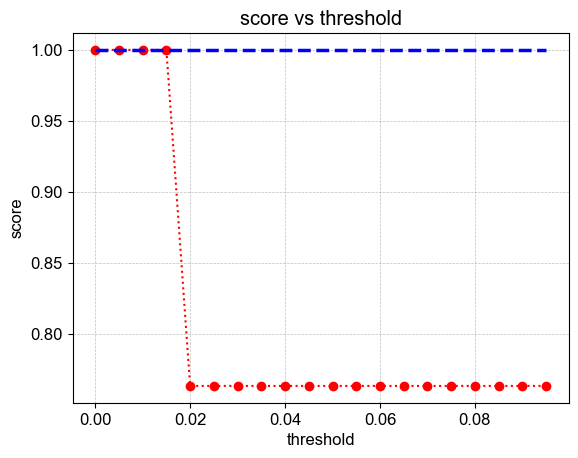

--------------------------------------------------
optimal_threshold: 0.015
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.742 r + -7.368 r_dot + -3.034 q
(q)' = 1.000 q_dot
(q_dot)' = 22.833 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999944581033656
Iteration: 1
[ 0.00149163 -0.02399193  0.03026273 -0.02825428]


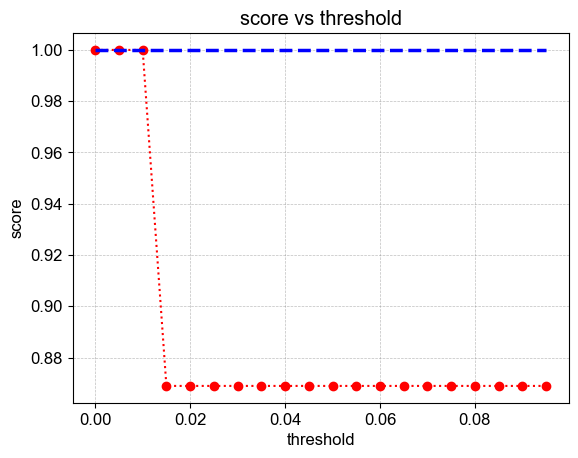

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.366 r + -7.364 r_dot + -3.030 q
(q)' = 1.000 q_dot
(q_dot)' = 22.810 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999985088039121
Iteration: 2
[-0.00259129  0.04222223  0.04852935  0.02343028]


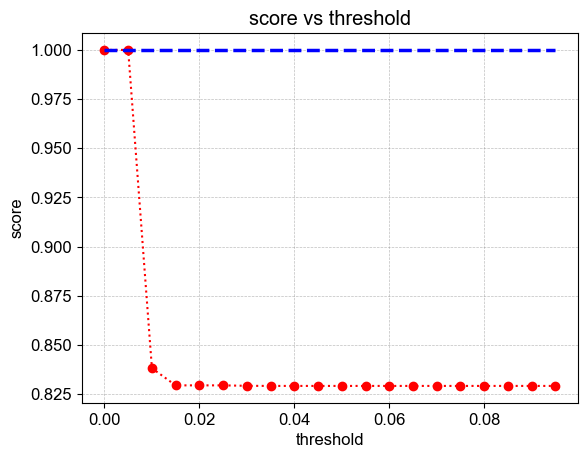

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot + 0.001 r_dot^2
(r_dot)' = -337.298 r + -7.323 r_dot + -3.030 q + -0.001 r_dot^2 + 0.055 r_dot^2 q + -0.093 r_dot^2 q_dot
(q)' = 0.001 r_dot + 1.000 q_dot
(q_dot)' = 22.801 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999998470460308
Iteration: 3
[-0.03100919  0.02746421  0.0407454  -0.00046496]


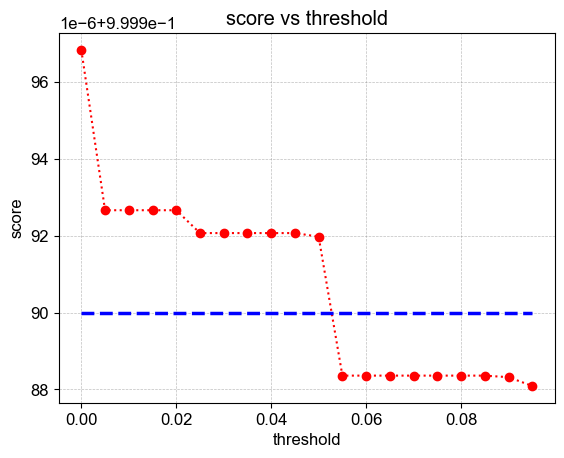

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.140 r + -7.322 r_dot + -3.037 q + 0.395 r^2 + -107.342 r^2 r_dot + 0.535 r_dot^2 q + 1.143 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919755554035
Iteration: 4
[-0.00660565 -0.00775464  0.04534599  0.026656  ]


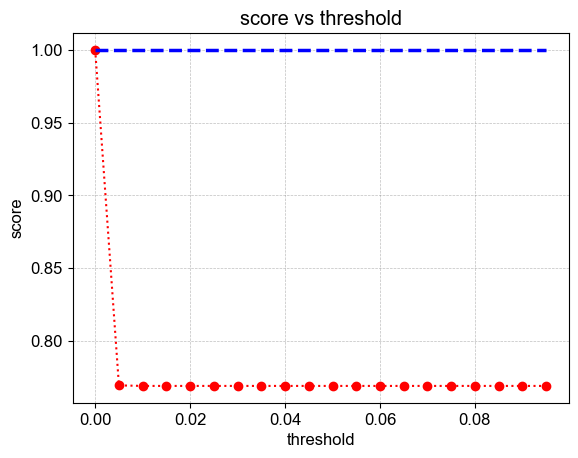

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.013 r + 0.995 r_dot + 0.126 r^2 + 0.009 r_dot^2 + -122.455 r^2 r_dot + -0.029 r^2 q + -1.729 r^2 q_dot + -0.028 r_dot^2 q + 0.001 r_dot^2 q_dot
(r_dot)' = -338.344 r + -7.327 r_dot + -3.039 q + 0.001 q_dot + 4.483 r^2 + 0.318 r_dot^2 + -4363.852 r^2 r_dot + -1.029 r^2 q + -61.623 r^2 q_dot + -0.986 r_dot^2 q + 0.033 r_dot^2 q_dot + 0.002 q^2 q_dot
(q)' = -0.003 r + 1.000 q_dot + 0.004 r^2 + 0.004 r_dot^2 + -11.372 r^2 r_dot + 0.076 r^2 q + 1.162 r^2 q_dot + -0.067 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.879 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.585 r^2 + -0.175 r_dot^2 + 317.225 r^2 r_dot + 0.009 r^2 q + 77.454 r^2 q_dot + 3.291 r_dot^2 q + -0.157 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.9999957195343099
Iteration: 5
[-0.04417177 -0.0414808  -0.00348049 -0.01931989]


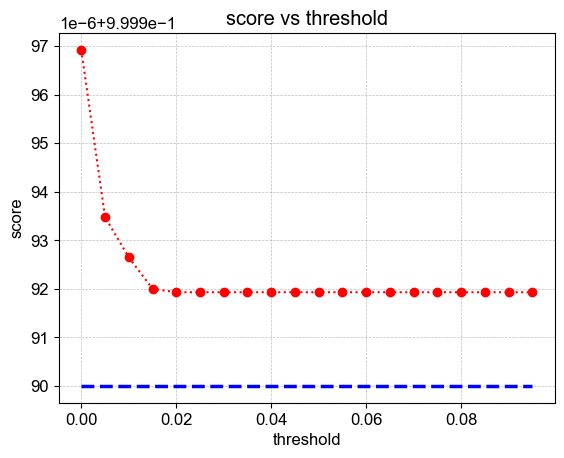

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.246 r + -7.346 r_dot + -3.038 q + 1.288 r^2 + 0.059 r_dot^2 + -82.716 r^2 r_dot + 0.772 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919303751272
Iteration: 6
[ 0.04763776  0.03942089 -0.02418305 -0.03562768]


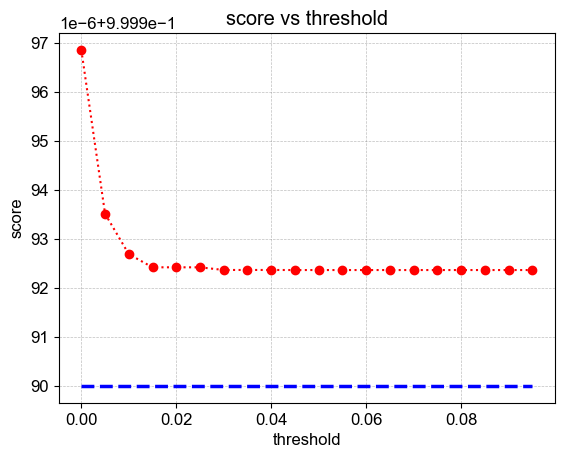

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.359 r + -7.311 r_dot + -3.039 q + -1.482 r^2 + -0.037 r_dot^2 + -94.040 r^2 r_dot + -0.576 r_dot^2 q + 1.688 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.073 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999923665958208
Iteration: 7
[-0.00333967 -0.03114593 -0.03651115 -0.02003754]


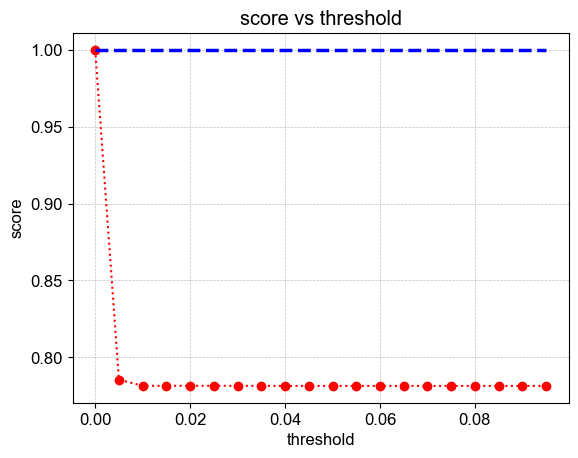

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.038 r + 0.995 r_dot + 0.010 r^2 + 0.004 r_dot^2 + -48.737 r^2 r_dot + -0.011 r^2 q + -0.992 r^2 q_dot + -0.024 r_dot^2 q
(r_dot)' = -337.949 r + -7.353 r_dot + -3.036 q + 1.705 r^2 + 0.686 r_dot^2 + -8688.254 r^2 r_dot + -1.950 r^2 q + -176.879 r^2 q_dot + -4.286 r_dot^2 q + 0.062 r_dot^2 q_dot + 0.008 q^2 q_dot
(q)' = -0.004 r + 0.001 r_dot + 1.000 q_dot + -0.011 r^2 + -0.007 r_dot^2 + -140.387 r^2 r_dot + 0.047 r^2 q + -1.434 r^2 q_dot + -0.130 r_dot^2 q
(q_dot)' = 22.846 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + 0.093 r^2 + 0.084 r_dot^2 + 774.949 r^2 r_dot + 0.108 r^2 q + 88.757 r^2 q_dot + 3.601 r_dot^2 q + -0.160 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999951980248798
Iteration: 8
[ 0.01313357  0.02689885 -0.03113904 -0.03051787]


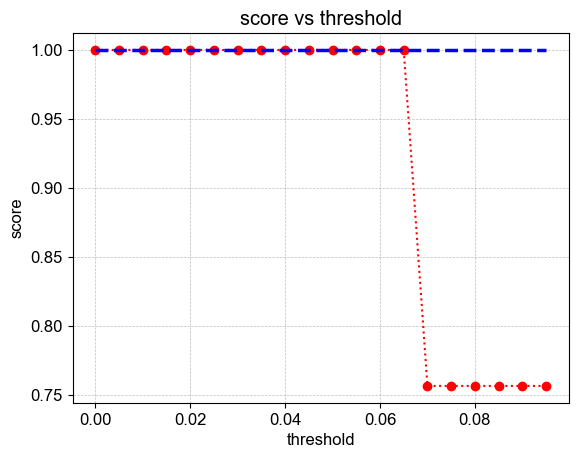

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.943 r + -7.373 r_dot + -3.036 q + -0.183 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.177 r + -1.251 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918553219802
Iteration: 9
[ 0.04769127 -0.03836893 -0.01643869 -0.0175444 ]


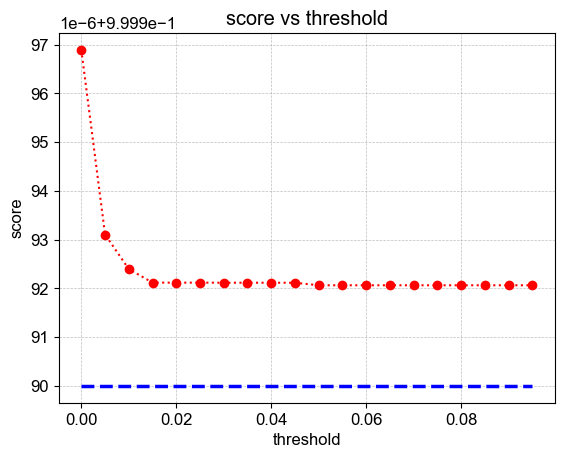

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.165 r + -7.310 r_dot + -3.038 q + -1.439 r^2 + -53.900 r^2 r_dot + 0.609 r_dot^2 q + 1.468 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920638990429
Iteration: 10
[-0.01182821 -0.04922977 -0.02805497 -0.01716067]


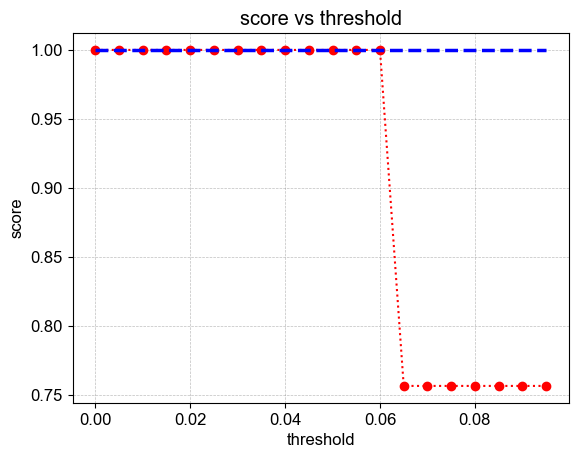

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.944 r + -7.375 r_dot + -3.036 q + 0.209 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.454 r + -1.249 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917760266481
Iteration: 11
[ 0.04761474  0.02198421 -0.04563892  0.03687069]


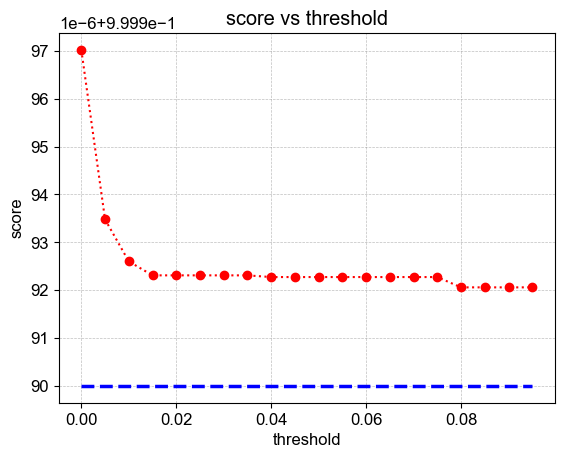

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.250 r + -7.325 r_dot + -3.039 q + -1.431 r^2 + -75.204 r^2 r_dot + 2.065 r_dot^2 q + 0.803 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.067 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999920589173177
Iteration: 12
[-0.0253354   0.04266357  0.01582368 -0.00966377]


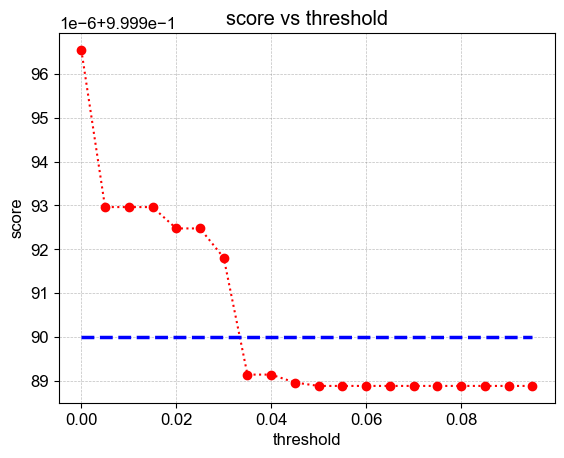

--------------------------------------------------
optimal_threshold: 0.03
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.969 r + -7.357 r_dot + -3.036 q + 0.182 r^2 + 0.071 r_dot^2 + -57.703 r^2 r_dot + 0.366 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918102257066
Iteration: 13
[ 0.00854211 -0.02400793 -0.02745208 -0.01524059]


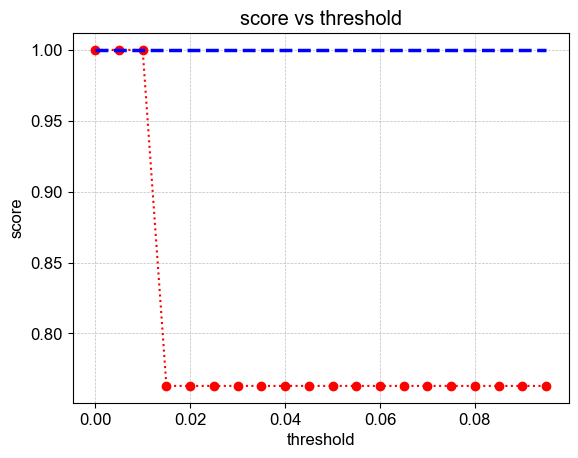

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.842 r + -7.371 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.530 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999936369711822
Iteration: 14
[ 0.01697751 -0.04089301  0.02968683 -0.00436779]


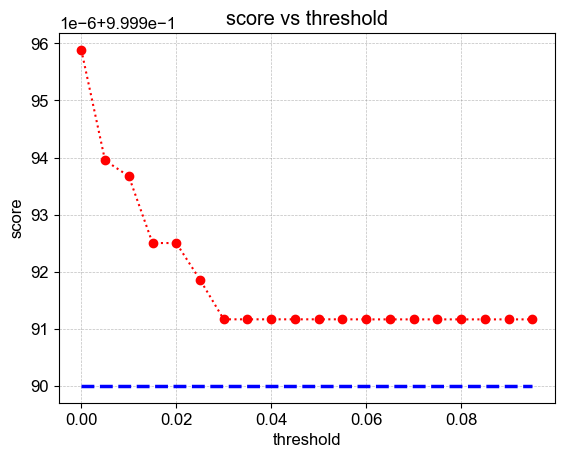

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.859 r + -7.362 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.592 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999911655534925
Iteration: 15
[-0.04064656  0.0027927  -0.01257427  0.02643203]


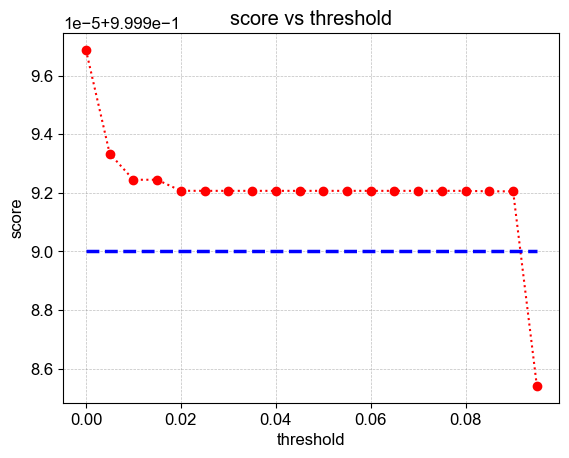

--------------------------------------------------
optimal_threshold: 0.09
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.265 r + -7.313 r_dot + -3.039 q + 0.939 r^2 + -95.211 r^2 r_dot + 1.538 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920500757018
Iteration: 16
[-0.03648699  0.00674005  0.0086705  -0.00678574]


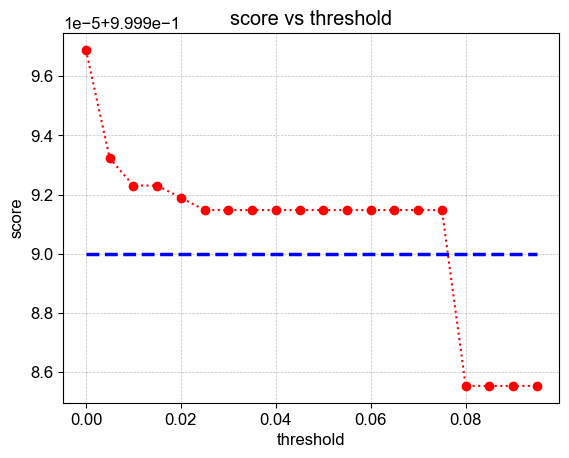

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.088 r + -7.342 r_dot + -3.037 q + 0.792 r^2 + -61.762 r^2 r_dot + 1.180 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914782412187
Iteration: 17
[-0.02725371  0.02926975  0.0076611  -0.0463291 ]


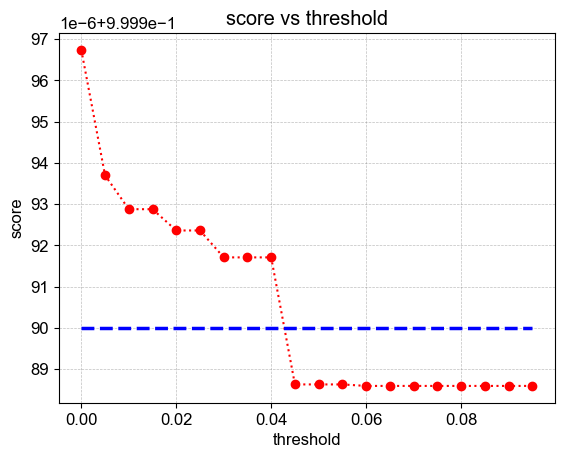

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.032 r + -7.357 r_dot + -3.036 q + 0.217 r^2 + 0.074 r_dot^2 + -78.597 r^2 r_dot + 0.374 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917066733797
Iteration: 18
[-0.01306457 -0.01212708 -0.01612037  0.03636665]


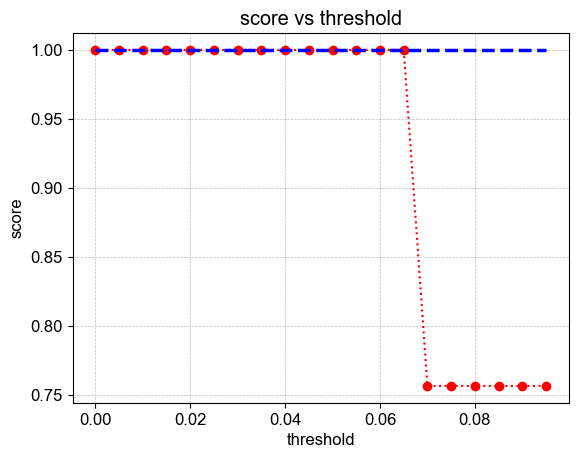

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.932 r + -7.369 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 20.014 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915700228357
Iteration: 19
[ 0.01218502  0.04635554 -0.03011984  0.00437793]


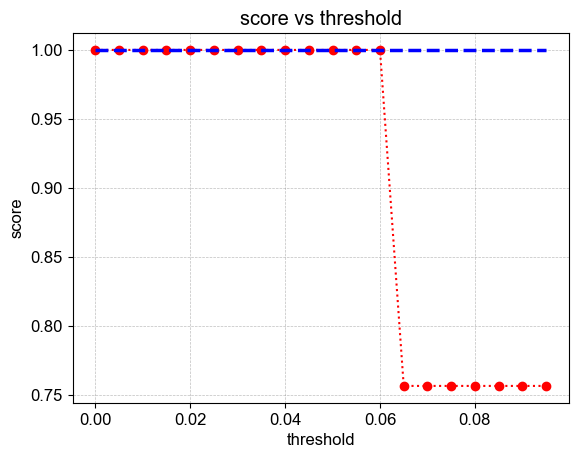

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.945 r + -7.374 r_dot + -3.036 q + -0.210 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.428 r + -1.249 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918406712957
Iteration: 20
[-0.04117995 -0.00104802 -0.01271031 -0.04306962]


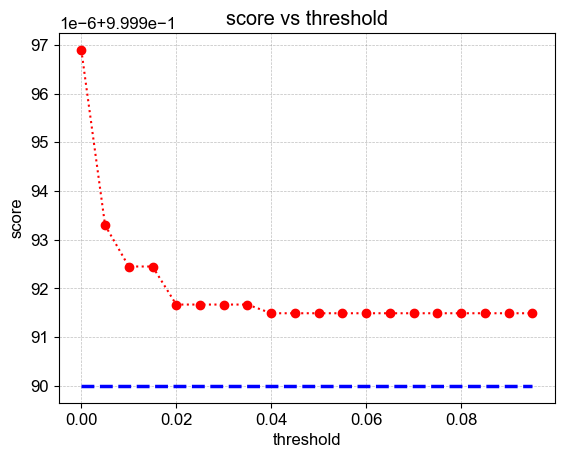

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.109 r + -7.344 r_dot + -3.037 q + 0.974 r^2 + -52.175 r^2 r_dot + -0.710 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914914357562
Iteration: 21
[-0.04485213 -0.01545982 -0.02326364 -0.04048973]


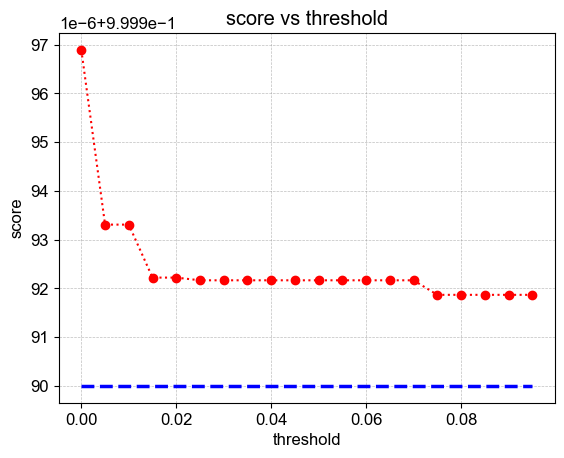

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.232 r + -7.320 r_dot + -3.038 q + 1.247 r^2 + -68.483 r^2 r_dot + -2.356 r_dot^2 q + 1.059 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918675283948
Iteration: 22
[-0.02173678 -0.03616046  0.00287594  0.00853015]


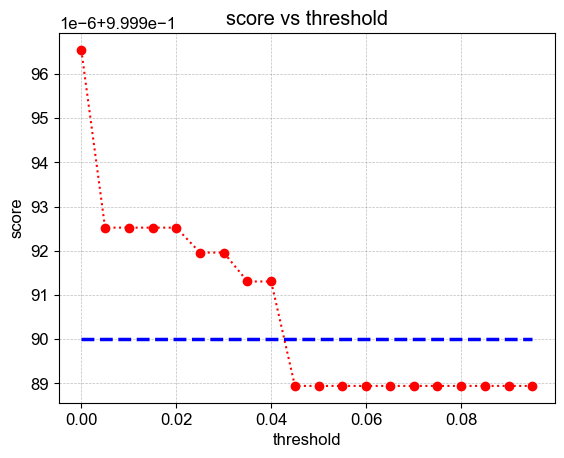

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.940 r + -7.367 r_dot + -3.036 q + 0.096 r^2 + 0.095 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913069556279
Iteration: 23
[ 0.0382081   0.00500219  0.02466076 -0.00193494]


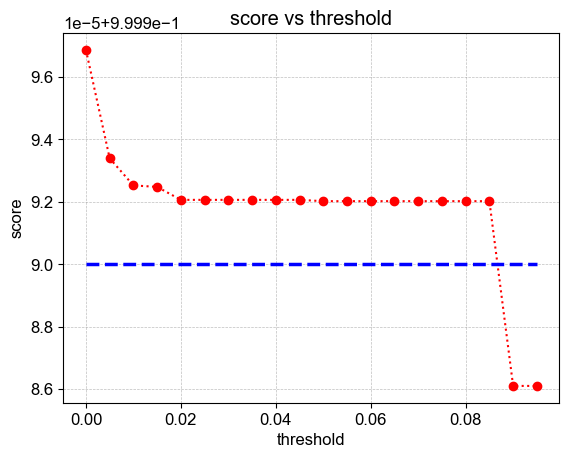

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.281 r + -7.313 r_dot + -3.039 q + -0.804 r^2 + -110.679 r^2 r_dot + -1.249 r_dot^2 q + 1.586 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920229235717
Iteration: 24
[ 0.04496625 -0.03061547 -0.01840359  0.00594675]


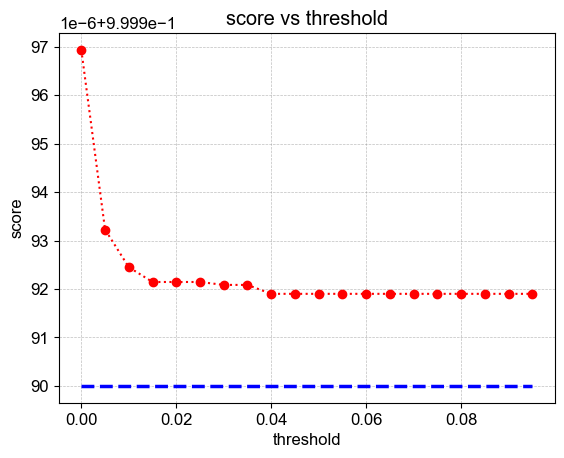

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.122 r + -7.318 r_dot + -3.037 q + -1.285 r^2 + -51.822 r^2 r_dot + 1.453 r_dot^2 q + 1.007 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919003084319
Iteration: 25
[0.04467399 0.03824135 0.02277736 0.01565547]


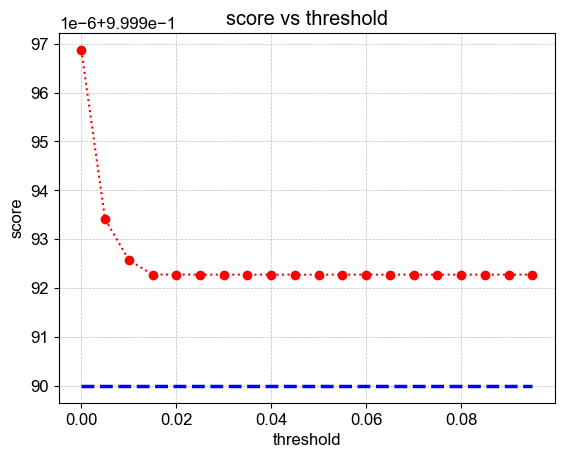

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.351 r + -7.312 r_dot + -3.039 q + -1.254 r^2 + -0.082 r_dot^2 + -101.958 r^2 r_dot + -0.340 r_dot^2 q + 1.582 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922762425664
Iteration: 26
[-0.00942519 -0.01986024 -0.00555522  0.00373172]


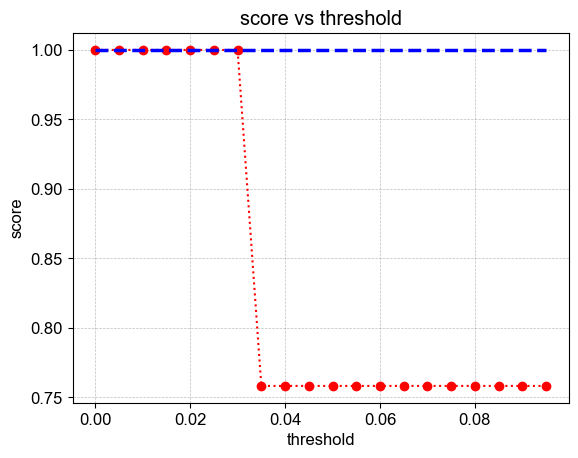

--------------------------------------------------
optimal_threshold: 0.03
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.943 r + -7.374 r_dot + -3.036 q + 0.224 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.180 r + -1.251 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999924957673477
Iteration: 27
[-0.04418868 -0.00215815  0.00158129  0.0214723 ]


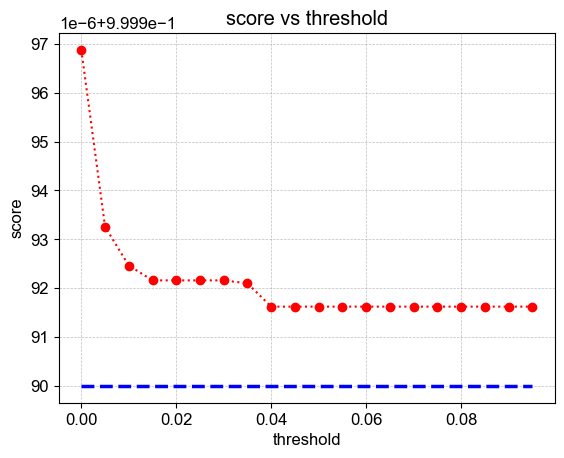

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.110 r + -7.337 r_dot + -3.037 q + 1.288 r^2 + -48.706 r^2 r_dot + 0.954 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916223076819
Iteration: 28
[ 0.03795528 -0.04381435  0.00169465 -0.02946696]


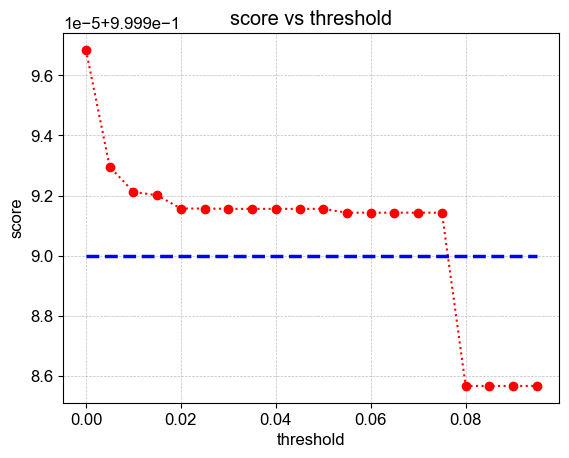

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -337.956 r + -7.345 r_dot + -3.036 q + -0.698 r^2 + -20.651 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914317028032
Iteration: 29
[-0.03407861 -0.01153846  0.01544314 -0.04570214]


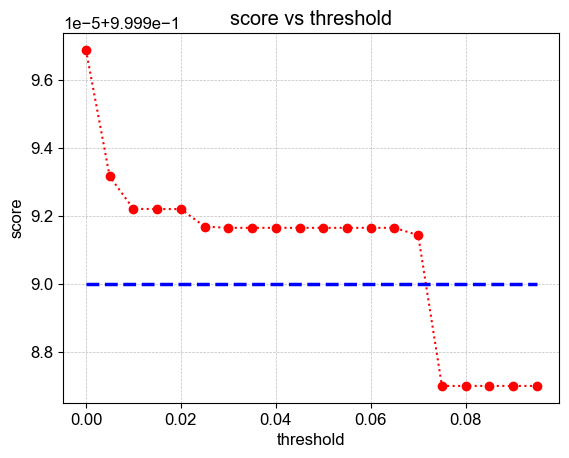

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.126 r + -7.344 r_dot + -3.037 q + 0.571 r^2 + -84.329 r^2 r_dot + 1.219 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914268173863
Iteration: 30
[ 0.01338234 -0.0071456   0.02792149 -0.03290351]


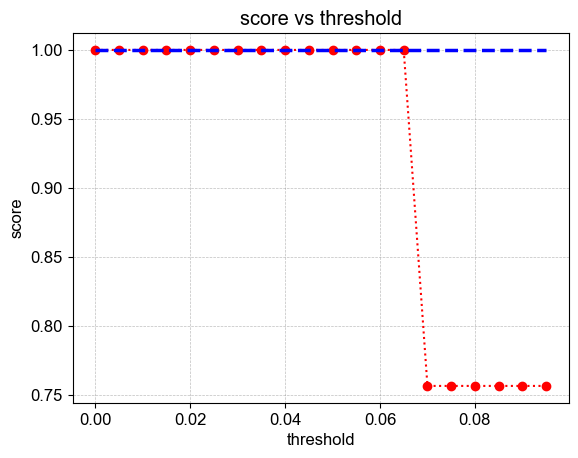

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.907 r + -7.368 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.820 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917631102544
Iteration: 31
[-0.03514194  0.03285454 -0.02170171  0.0001733 ]


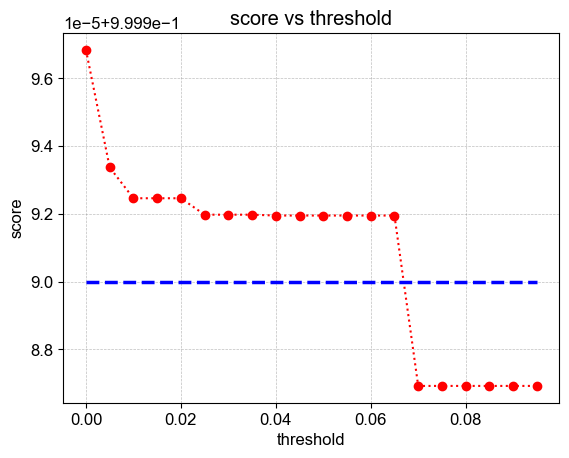

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.164 r + -7.317 r_dot + -3.037 q + 0.584 r^2 + -89.404 r^2 r_dot + -0.883 r_dot^2 q + 1.441 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919511292955
Iteration: 32
[ 0.0012966   0.02198261 -0.00677531 -0.00618832]


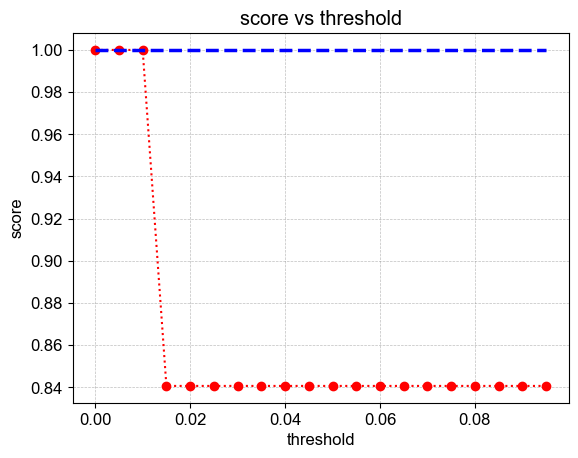

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.825 r + -7.374 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 22.837 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999954405489784
Iteration: 33
[-0.02169826 -0.00445997  0.03657497  0.0218393 ]


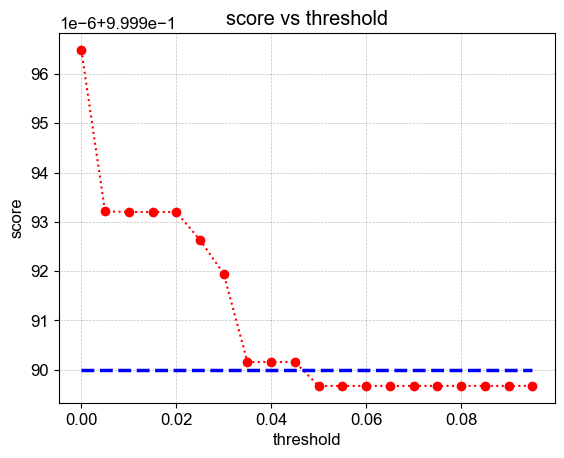

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.924 r + -7.343 r_dot + -3.035 q + 0.114 r^2 + 0.768 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.919 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999901563125152
Iteration: 34
[-0.02100691 -0.01817118  0.03563689 -0.03129339]


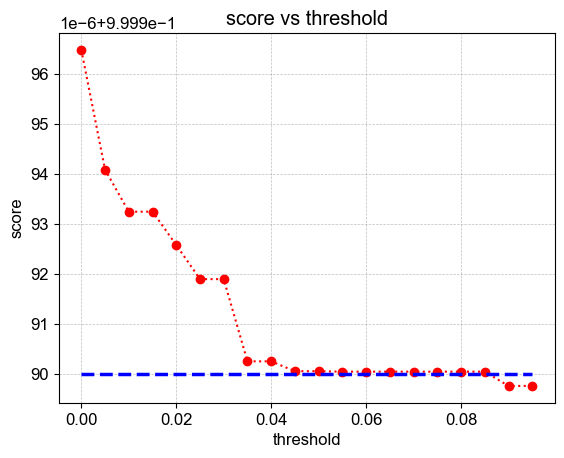

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.932 r + -7.368 r_dot + -3.035 q + 0.050 r^2 + 0.103 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.014 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999900491022525
Iteration: 35
[ 0.03219778  0.03964179 -0.00884384  0.01178657]


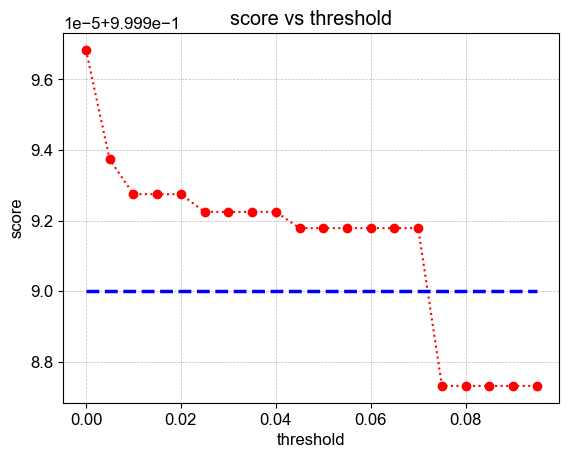

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.258 r + -7.351 r_dot + -3.038 q + -0.495 r^2 + -0.083 r_dot^2 + -154.923 r^2 r_dot + 0.460 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917886845027
Iteration: 36
[-0.0205761  -0.04117908 -0.00940134  0.03765755]


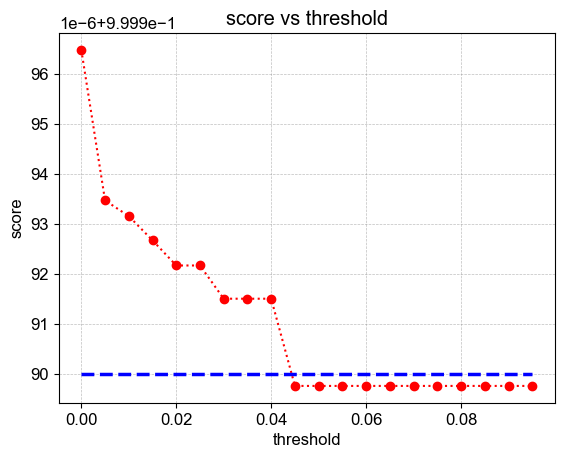

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.942 r + -7.369 r_dot + -3.036 q + 0.045 r^2 + 0.108 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.002 r_dot^2 + -0.287 q^2 q_dot
Score on training data:
0.9999915020683624
Iteration: 37
[-0.01132721 -0.03543481 -0.02502462  0.03440535]


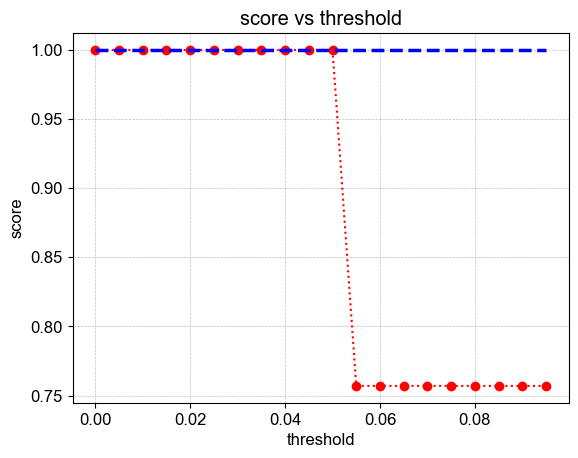

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.946 r + -7.374 r_dot + -3.036 q + 0.206 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.311 r + -1.250 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920656770868
Iteration: 38
[ 0.04546812 -0.01608129 -0.04207635 -0.00187888]


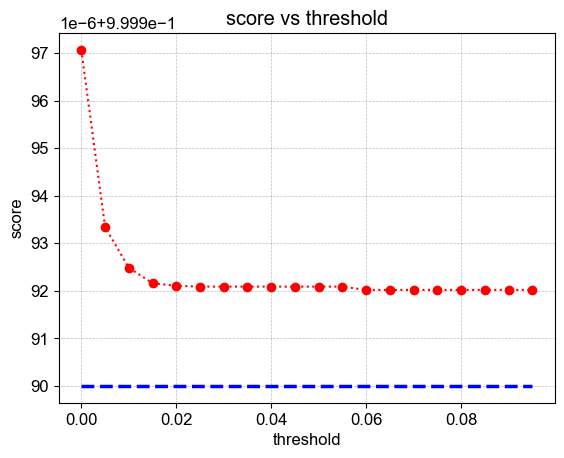

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.211 r + -7.317 r_dot + -3.038 q + -1.226 r^2 + -68.982 r^2 r_dot + 1.157 r_dot^2 q + 1.244 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920184259887
Iteration: 39
[ 0.03100579  0.03959917 -0.04877271 -0.02116556]


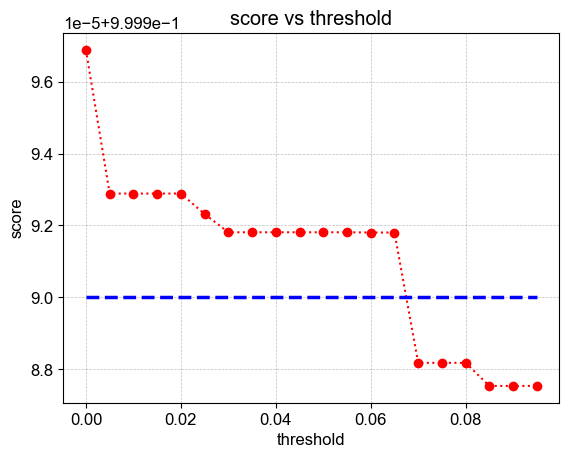

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.258 r + -7.354 r_dot + -3.038 q + -0.366 r^2 + -0.096 r_dot^2 + -164.409 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918039087659
Iteration: 40
[-0.04863118 -0.03295642  0.00705028  0.00549346]


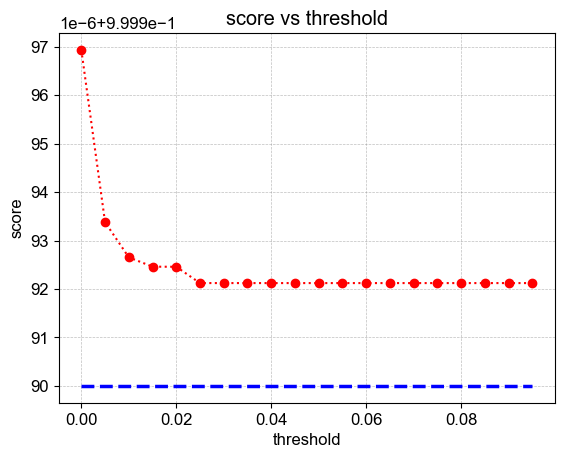

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.995 r_dot
(r_dot)' = -338.232 r + -7.341 r_dot + -3.038 q + 2.043 r^2 + 0.037 r_dot^2 + -67.629 r^2 r_dot + 0.777 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.098 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999921224803316
Iteration: 41
[-0.0049541  -0.04383396 -0.00086894 -0.02017647]


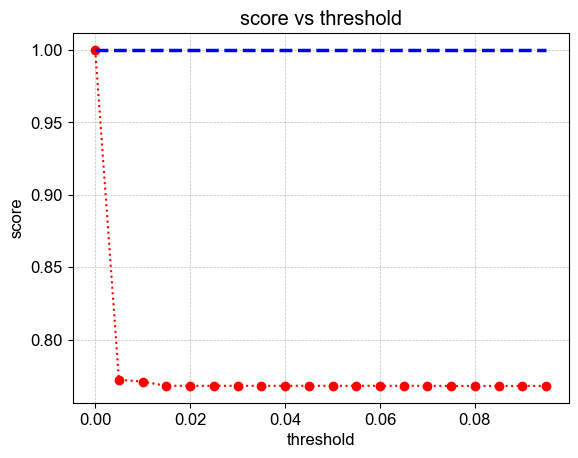

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.038 r + 0.995 r_dot + 0.012 r^2 + 0.003 r_dot^2 + -35.937 r^2 r_dot + -0.008 r^2 q + -0.723 r^2 q_dot + -0.017 r_dot^2 q
(r_dot)' = -338.015 r + -7.338 r_dot + -3.036 q + 2.497 r^2 + 0.658 r_dot^2 + -7343.371 r^2 r_dot + -1.660 r^2 q + -147.729 r^2 q_dot + -3.552 r_dot^2 q + 0.055 r_dot^2 q_dot + 0.007 q^2 q_dot
(q)' = -0.003 r + 1.000 q_dot + -0.001 r^2 + -0.001 r_dot^2 + -22.776 r^2 r_dot + 0.074 r^2 q + 0.989 r^2 q_dot + -0.070 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.849 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.134 r^2 + -0.031 r_dot^2 + 538.871 r^2 r_dot + 0.056 r^2 q + 84.120 r^2 q_dot + 3.491 r_dot^2 q + -0.158 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999956755409949
Iteration: 42
[ 0.03873335  0.01123322  0.01497867 -0.00283651]


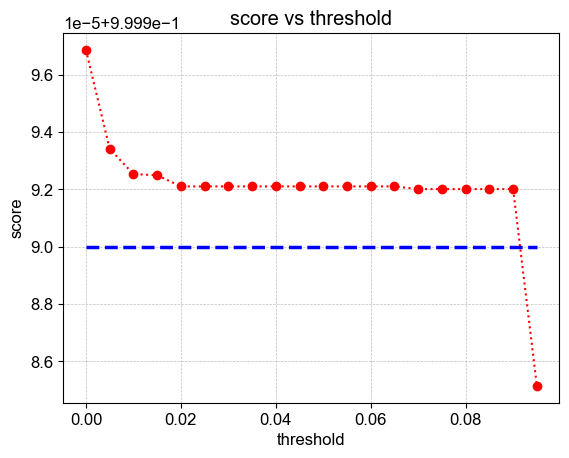

--------------------------------------------------
optimal_threshold: 0.09
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.280 r + -7.310 r_dot + -3.038 q + -0.886 r^2 + -108.214 r^2 r_dot + -1.399 r_dot^2 q + 1.629 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920100004303
Iteration: 43
[-0.03399308 -0.04446474 -0.02723616 -0.03155005]


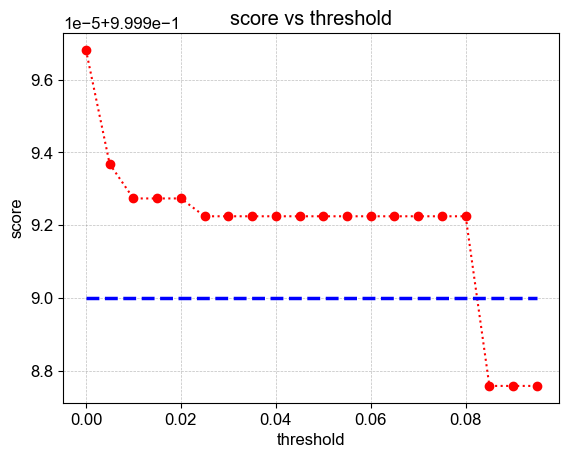

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.366 r + -7.318 r_dot + -3.039 q + 0.544 r^2 + 0.096 r_dot^2 + -181.145 r^2 r_dot + -0.464 r_dot^2 q + 1.402 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922421911422
Iteration: 44
[ 0.04353992 -0.0247663  -0.00605714 -0.02492979]


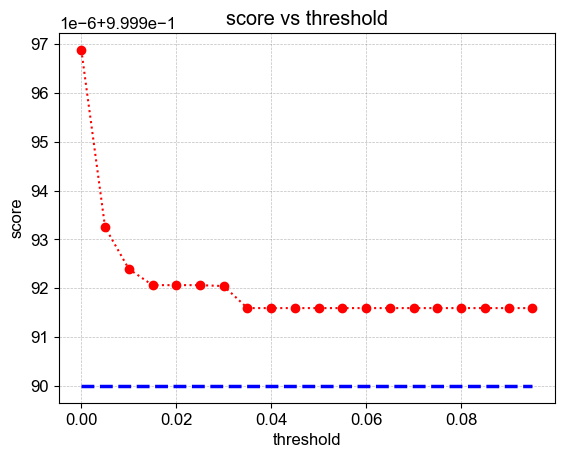

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.054 r + -7.340 r_dot + -3.037 q + -1.129 r^2 + -37.547 r^2 r_dot + 1.206 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915933919367
Iteration: 45
[-0.0258396  -0.02335196  0.00234234  0.00846003]


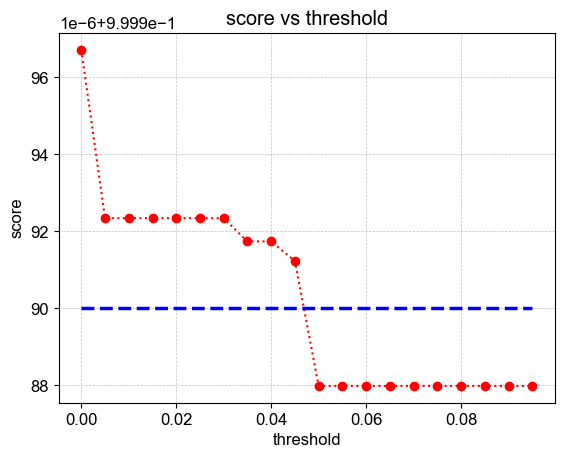

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.931 r + -7.363 r_dot + -3.035 q + 0.200 r^2 + 0.070 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999912331377099
Iteration: 46
[ 0.02034216 -0.02323133  0.00713167 -0.00858239]


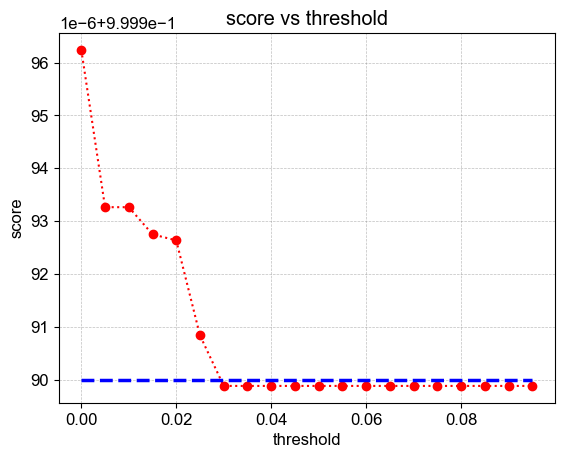

--------------------------------------------------
optimal_threshold: 0.025
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot + 0.013 r_dot^2
(r_dot)' = -337.893 r + -7.365 r_dot + -3.035 q + -0.054 r^2 + -0.097 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 19.743 r + -1.255 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999990838067546
Iteration: 47
[-0.04298405  0.0404226   0.00781061 -0.0185806 ]


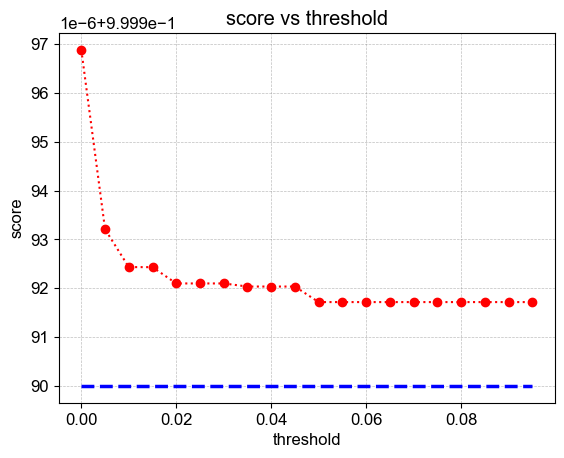

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.032 r + -7.322 r_dot + -3.036 q + 1.101 r^2 + -35.128 r^2 r_dot + 0.783 r_dot^2 q + 0.724 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917169062927
Iteration: 48
[-0.01814878  0.03984832  0.04819201 -0.01963662]


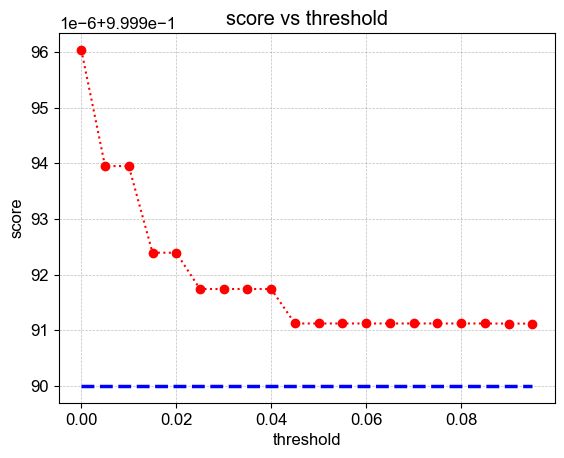

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.863 r + -7.362 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.607 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999911197536344
Iteration: 49
[ 0.02568094  0.00392017 -0.02239863  0.04151805]


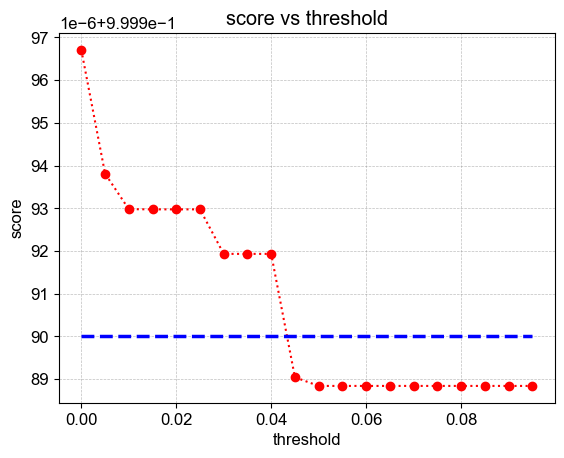

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.173 r + -7.320 r_dot + -3.038 q + -0.251 r^2 + -172.731 r^2 r_dot + 0.394 r_dot^2 q + 1.001 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919326061631
Iteration: 50
[-0.02107243  0.01128154  0.04072095  0.00770304]


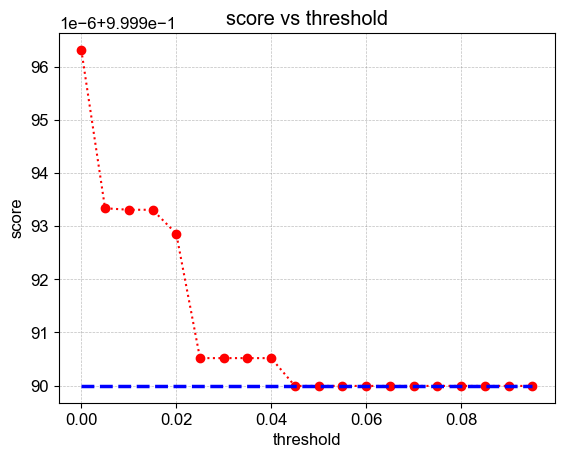

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.909 r + -7.341 r_dot + -3.035 q + 0.111 r^2 + 0.799 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.820 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999905164420753
Iteration: 51
[0.03472738 0.02129113 0.03121499 0.04638048]


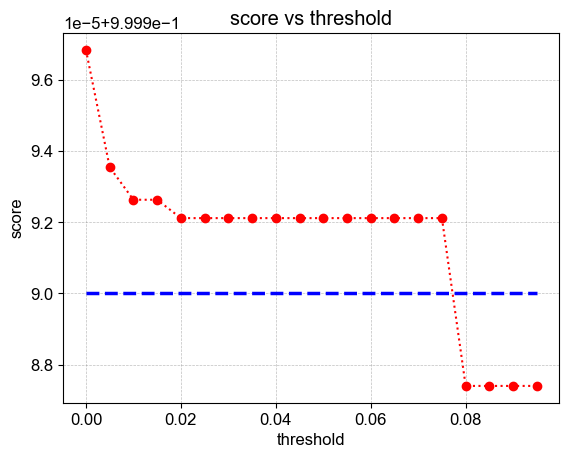

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.327 r + -7.318 r_dot + -3.039 q + -0.553 r^2 + -0.105 r_dot^2 + -153.004 r^2 r_dot + -0.433 r_dot^2 q + 1.395 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921189215112
Iteration: 52
[ 0.04261878 -0.04976586  0.03591502 -0.01839782]


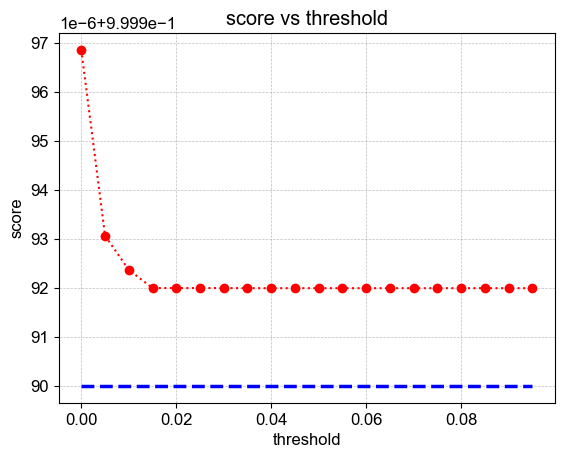

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.146 r + -7.317 r_dot + -3.037 q + -0.919 r^2 + -58.380 r^2 r_dot + -0.220 r_dot^2 q + 1.403 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919957555621
Iteration: 53
[ 0.04199088 -0.00368599 -0.02970683 -0.00653654]


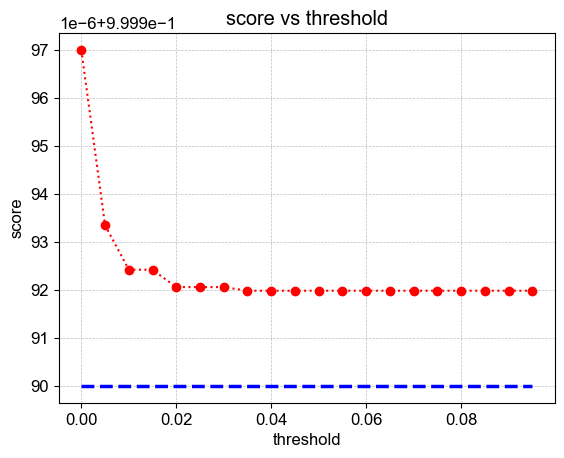

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.229 r + -7.316 r_dot + -3.038 q + -1.046 r^2 + -83.487 r^2 r_dot + 1.107 r_dot^2 q + 1.266 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919851369449
Iteration: 54
[-0.00731296  0.01429679 -0.03068768 -0.03065087]


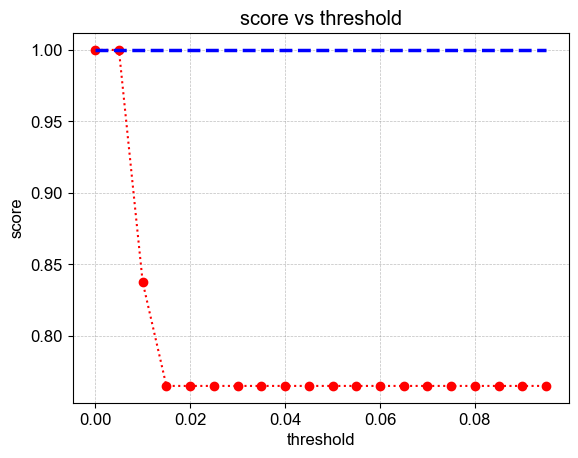

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.893 r + -7.360 r_dot + -3.035 q + -0.079 r_dot^2 q + 0.361 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.654 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999939742981125
Iteration: 55
[ 0.03931864  0.00581763 -0.02493773 -0.02332917]


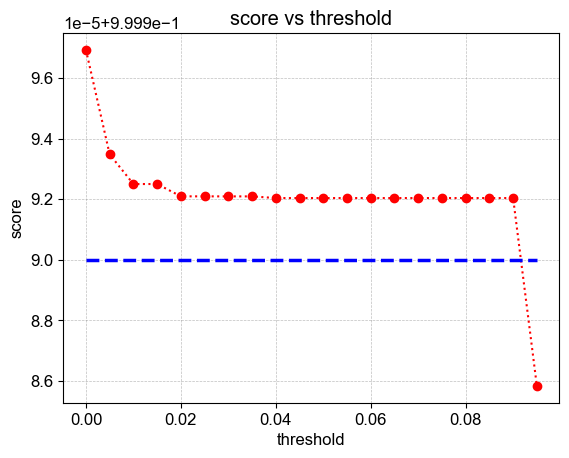

--------------------------------------------------
optimal_threshold: 0.09
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.274 r + -7.314 r_dot + -3.039 q + -0.871 r^2 + -105.818 r^2 r_dot + 0.444 r_dot^2 q + 1.446 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920397829929
Iteration: 56
[-0.01252646  0.03020995 -0.02514703 -0.03197145]


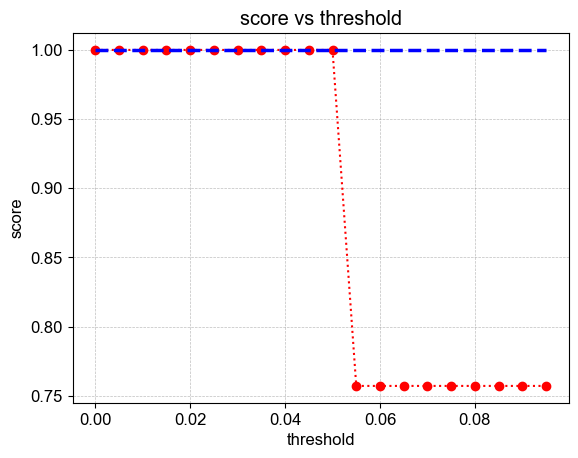

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.860 r + -7.367 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.595 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992341368362
Iteration: 57
[ 0.01638101  0.04803755 -0.04928388  0.01920506]


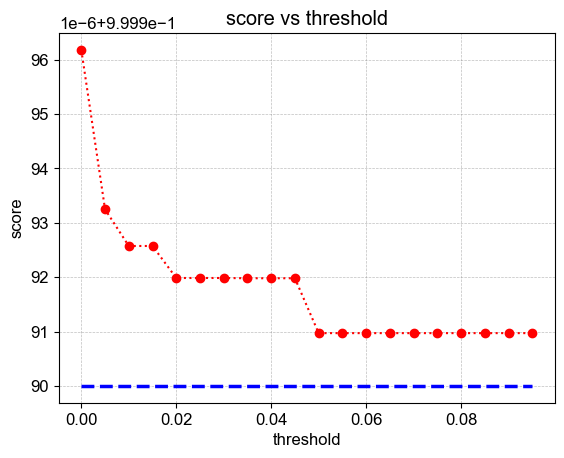

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.946 r + -7.373 r_dot + -3.036 q + 0.029 r^2 + -0.156 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.309 r + -1.250 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999909708959717
Iteration: 58
[-0.01240212  0.01748413 -0.00744159 -0.034199  ]


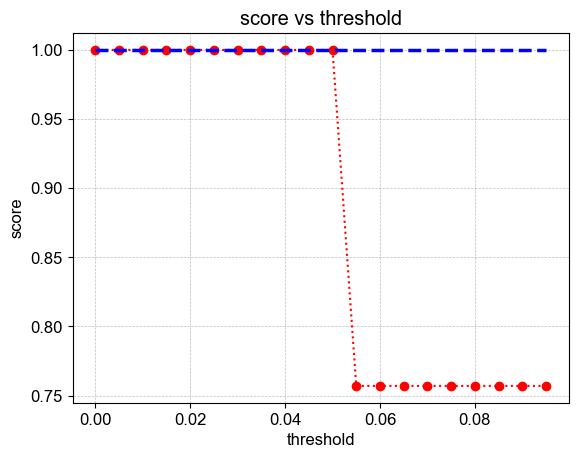

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.888 r + -7.368 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.713 r + -1.255 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921768608016
Iteration: 59
[ 0.02572021 -0.00142932 -0.0304363  -0.03877334]


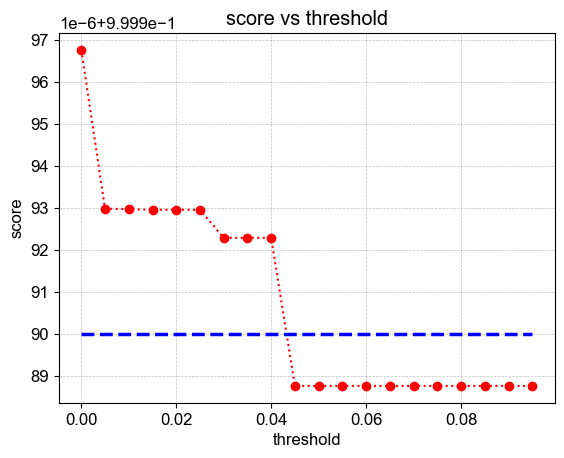

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.224 r + -7.323 r_dot + -3.038 q + -0.224 r^2 + -204.837 r^2 r_dot + 1.141 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922862288553
Iteration: 60
[-0.03985381 -0.04545054 -0.00257493  0.04491886]


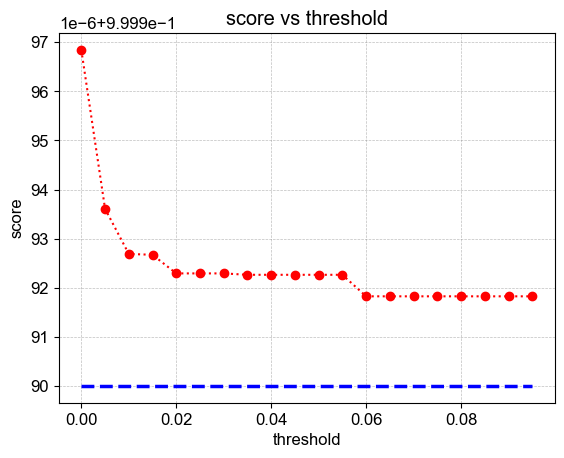

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.257 r + -7.349 r_dot + -3.038 q + 0.886 r^2 + 0.066 r_dot^2 + -102.292 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918248160764
Iteration: 61
[ 0.02393979 -0.04934017  0.01189623  0.00135782]


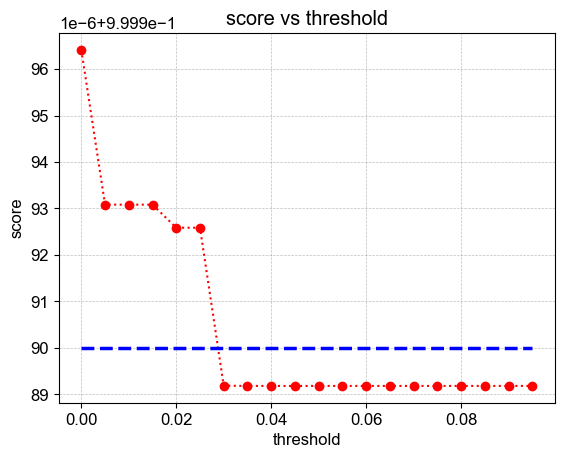

--------------------------------------------------
optimal_threshold: 0.025
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot + 0.011 r_dot^2
(r_dot)' = -337.932 r + -7.358 r_dot + -3.036 q + -0.130 r^2 + -0.082 r_dot^2 + -44.885 r^2 r_dot + 0.341 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.841 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992586213493
Iteration: 62
[ 0.026852   -0.03097717  0.01549296  0.00634396]


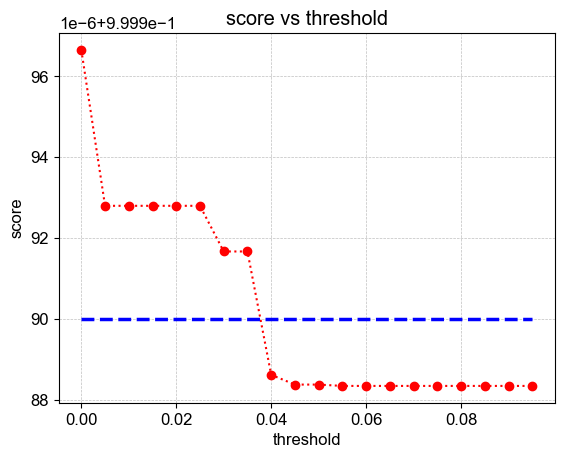

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.023 r + -7.356 r_dot + -3.036 q + -0.223 r^2 + -0.079 r_dot^2 + -76.385 r^2 r_dot + 0.362 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916737700201
Iteration: 63
[0.04342686 0.00671474 0.00354954 0.00237357]


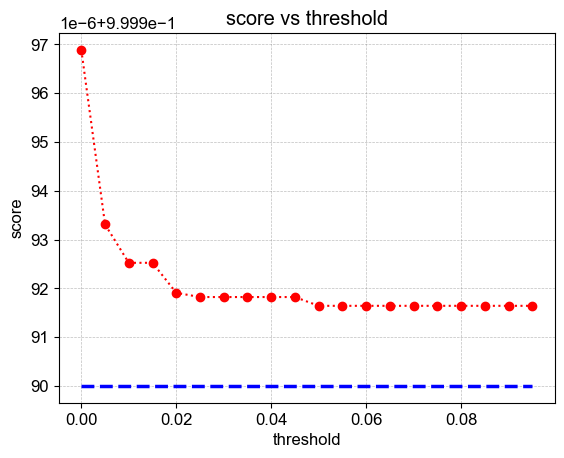

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.120 r + -7.337 r_dot + -3.037 q + -1.374 r^2 + -52.286 r^2 r_dot + 0.058 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916418515138
Iteration: 64
[ 0.02713227  0.02149884  0.02205698 -0.01155108]


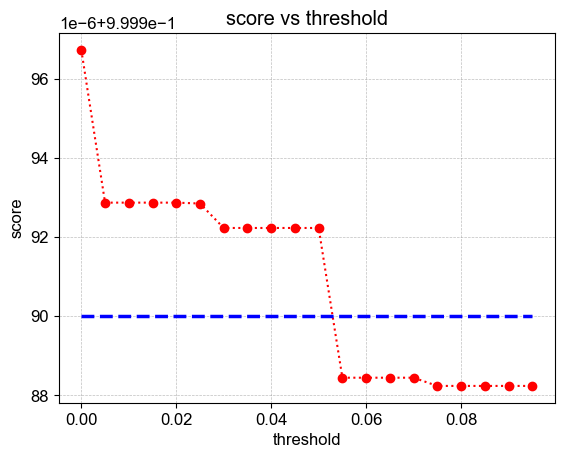

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.294 r + -7.321 r_dot + -3.039 q + -0.280 r^2 + -0.040 r_dot^2 + -232.077 r^2 r_dot + 1.179 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922279651854
Iteration: 65
[-0.03567563  0.02923872 -0.04898536  0.00124241]


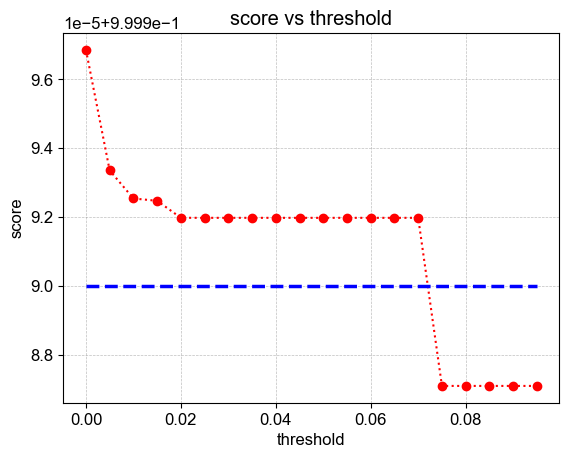

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.188 r + -7.319 r_dot + -3.038 q + 0.577 r^2 + -94.090 r^2 r_dot + -0.556 r_dot^2 q + 1.385 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919752604296
Iteration: 66
[ 0.03451953  0.01681036 -0.04834912  0.03532992]


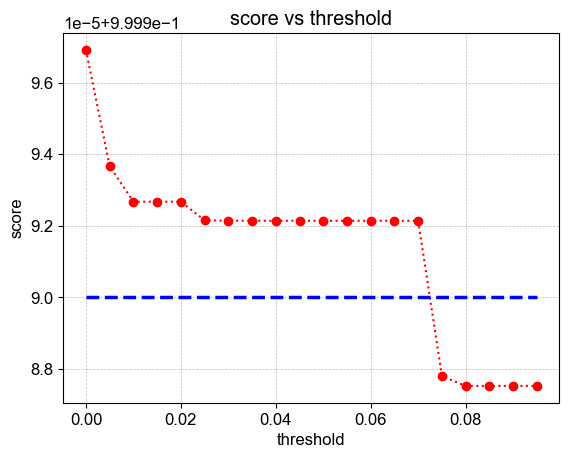

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.326 r + -7.321 r_dot + -3.039 q + -0.480 r^2 + -0.140 r_dot^2 + -155.209 r^2 r_dot + -0.400 r_dot^2 q + 1.331 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992139225153
Iteration: 67
[-0.02569492  0.04013597 -0.01596004 -0.04941727]


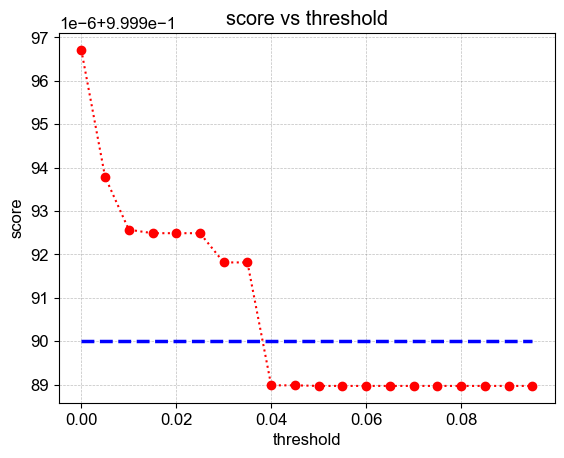

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.975 r + -7.358 r_dot + -3.036 q + 0.166 r^2 + 0.083 r_dot^2 + -58.332 r^2 r_dot + 0.349 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918153714219
Iteration: 68
[-0.00071909 -0.021017   -0.0291985   0.02837833]


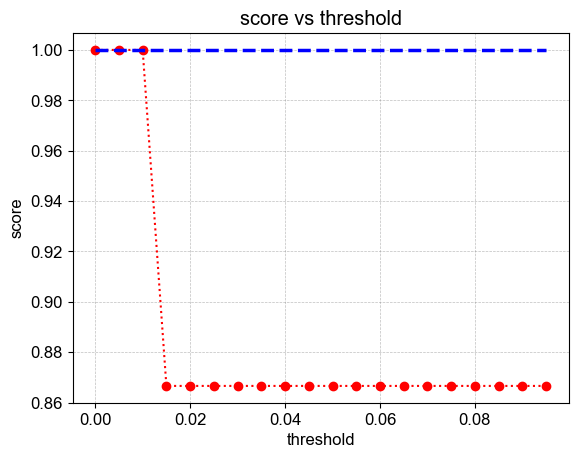

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.803 r + -7.374 r_dot + -3.034 q
(q)' = 1.000 q_dot
(q_dot)' = 22.833 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999962665677018
Iteration: 69
[ 0.0154125   0.00719092  0.0230064  -0.04194119]


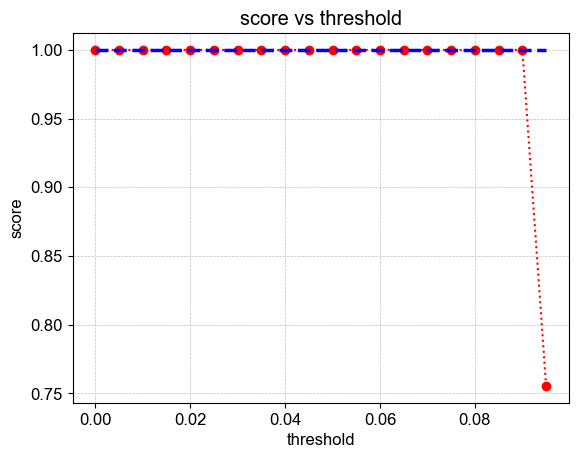

--------------------------------------------------
optimal_threshold: 0.09
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.925 r + -7.367 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.951 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999910693162146
Iteration: 70
[ 0.02992571 -0.03062006 -0.00322684 -0.03849898]


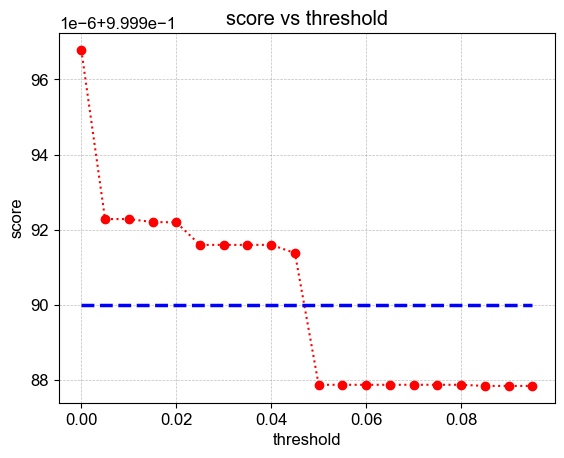

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.971 r + -7.350 r_dot + -3.036 q + -0.360 r^2 + -36.658 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913757543466
Iteration: 71
[ 0.02235611 -0.04680726 -0.00836994 -0.01262456]


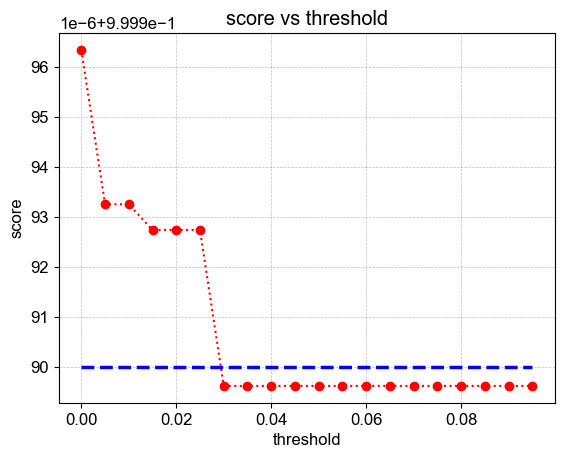

--------------------------------------------------
optimal_threshold: 0.025
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot + 0.012 r_dot^2
(r_dot)' = -337.936 r + -7.360 r_dot + -3.036 q + -0.103 r^2 + -0.090 r_dot^2 + -55.102 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.841 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999927354620947
Iteration: 72
[-0.00588175  0.03631353 -0.04366669 -0.04874966]


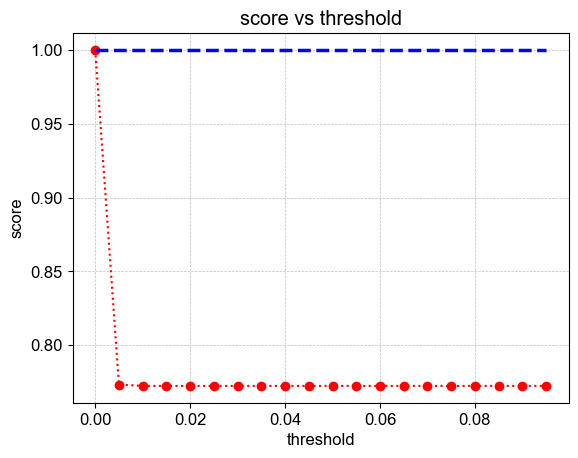

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.024 r + 0.995 r_dot + 0.101 r^2 + -0.006 r_dot^2 + 147.949 r^2 r_dot + 0.036 r^2 q + 1.103 r^2 q_dot + -0.009 r_dot^2 q + -0.001 r_dot^2 q_dot
(r_dot)' = -337.554 r + -7.329 r_dot + -3.032 q + 1.376 r^2 + -0.078 r_dot^2 + 2004.902 r^2 r_dot + 0.485 r^2 q + 14.974 r^2 q_dot + -0.117 r_dot^2 q + -0.012 r_dot^2 q_dot
(q)' = -0.004 r + 1.000 q_dot + 0.004 r^2 + -0.003 r_dot^2 + -33.885 r^2 r_dot + 0.071 r^2 q + 0.877 r^2 q_dot + -0.071 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.828 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + 0.149 r^2 + 0.157 r_dot^2 + -52.943 r^2 r_dot + -0.079 r^2 q + 73.119 r^2 q_dot + 3.244 r_dot^2 q + -0.154 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.999997454700995
Iteration: 73
[-0.04059212  0.0453222   0.02051605 -0.02441328]


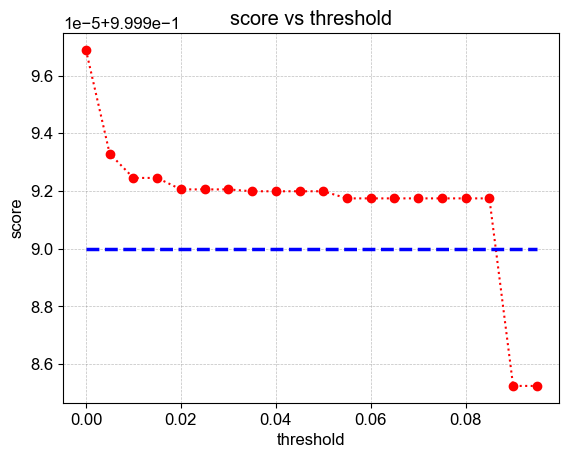

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.037 r + -7.325 r_dot + -3.037 q + 0.863 r^2 + -41.260 r^2 r_dot + 1.360 r_dot^2 q + 0.772 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917429697927
Iteration: 74
[-0.03678956 -0.02708786 -0.01929727  0.0011109 ]


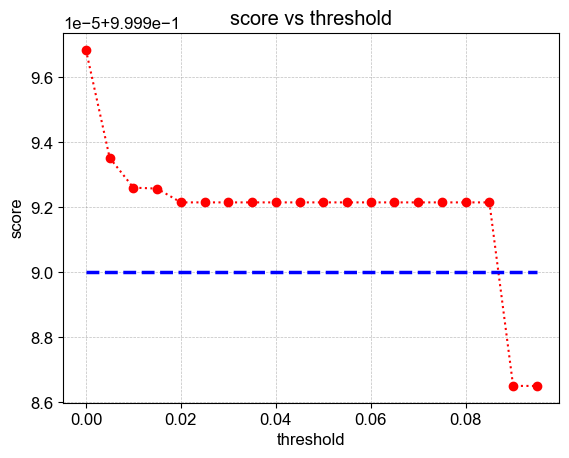

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.340 r + -7.317 r_dot + -3.039 q + 0.731 r^2 + 0.049 r_dot^2 + -142.719 r^2 r_dot + -0.490 r_dot^2 q + 1.454 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992155889514
Iteration: 75
[-0.02325497 -0.03135841 -0.04258978  0.04121112]


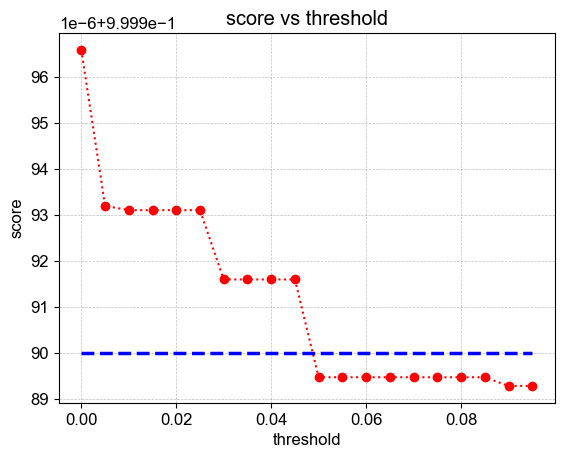

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.944 r + -7.349 r_dot + -3.036 q + 0.114 r^2 + 0.022 r_dot^2 + 0.619 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915979146634
Iteration: 76
[-0.04015136  0.03445286  0.04385357 -0.02204549]


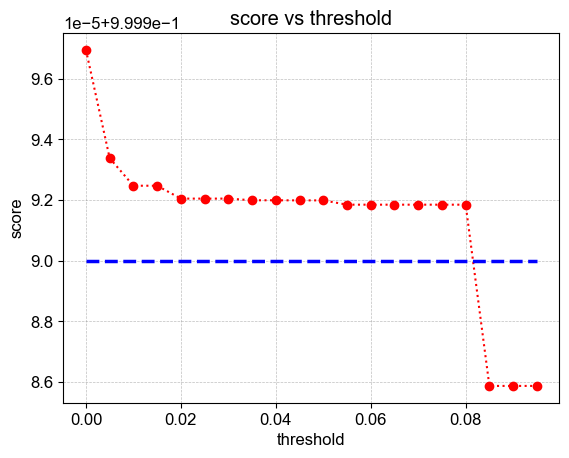

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.120 r + -7.324 r_dot + -3.037 q + 0.810 r^2 + -62.829 r^2 r_dot + 1.309 r_dot^2 q + 0.963 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918467651253
Iteration: 77
[-0.04324253 -0.04672038 -0.01856415 -0.01638317]


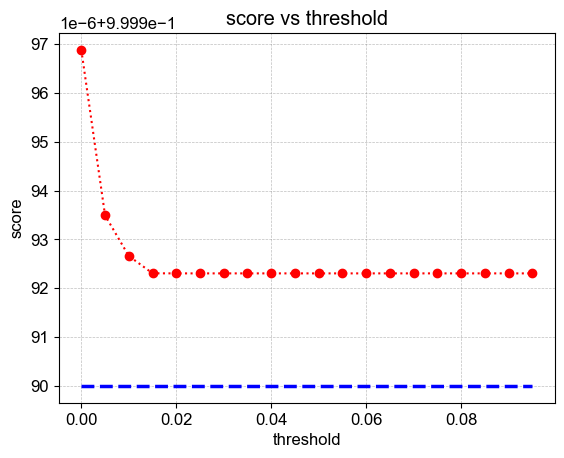

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.364 r + -7.313 r_dot + -3.039 q + 1.162 r^2 + 0.088 r_dot^2 + -112.911 r^2 r_dot + -0.351 r_dot^2 q + 1.572 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999923041666571
Iteration: 78
[ 0.04676297  0.01405868 -0.04954169  0.04433482]


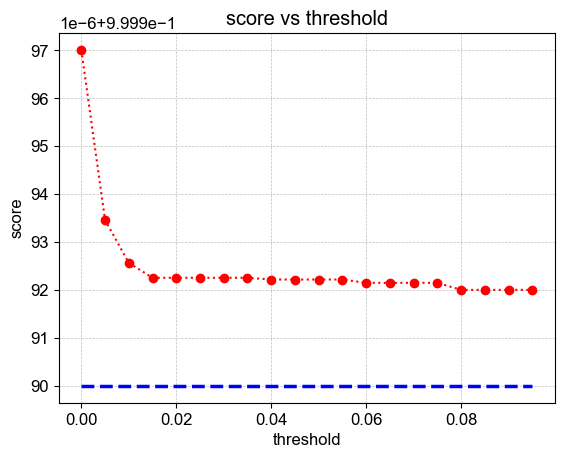

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.236 r + -7.327 r_dot + -3.038 q + -1.331 r^2 + -74.133 r^2 r_dot + 1.988 r_dot^2 q + 0.770 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.063 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999920039102944
Iteration: 79
[-0.00519326 -0.02148899  0.0390303   0.01291743]


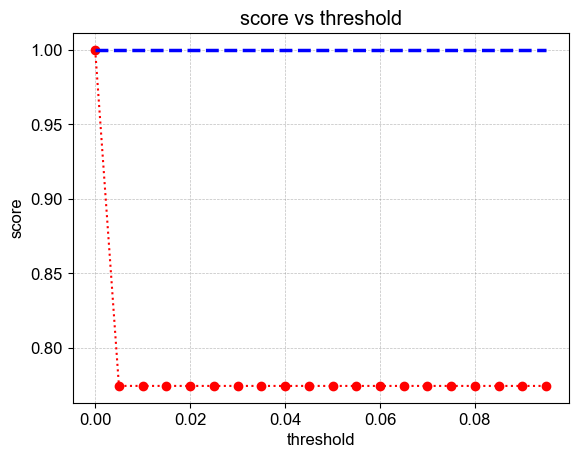

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.026 r + 0.995 r_dot + 0.050 r^2 + 0.012 r_dot^2 + -130.226 r^2 r_dot + -0.029 r^2 q + -2.581 r^2 q_dot + -0.061 r_dot^2 q + 0.001 r_dot^2 q_dot
(r_dot)' = -338.291 r + -7.333 r_dot + -3.039 q + 3.026 r^2 + 0.732 r_dot^2 + -7906.384 r^2 r_dot + -1.790 r^2 q + -156.659 r^2 q_dot + -3.713 r_dot^2 q + 0.058 r_dot^2 q_dot + 0.007 q^2 q_dot
(q)' = -0.004 r + 1.000 q_dot + 0.008 r^2 + 0.004 r_dot^2 + -36.135 r^2 r_dot + 0.070 r^2 q + 0.723 r^2 q_dot + -0.077 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.873 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.436 r^2 + -0.181 r_dot^2 + 597.788 r^2 r_dot + 0.069 r^2 q + 85.289 r^2 q_dot + 3.520 r_dot^2 q + -0.159 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999958967508553
Iteration: 80
[ 0.00696714 -0.02721091  0.01711867  0.03856709]


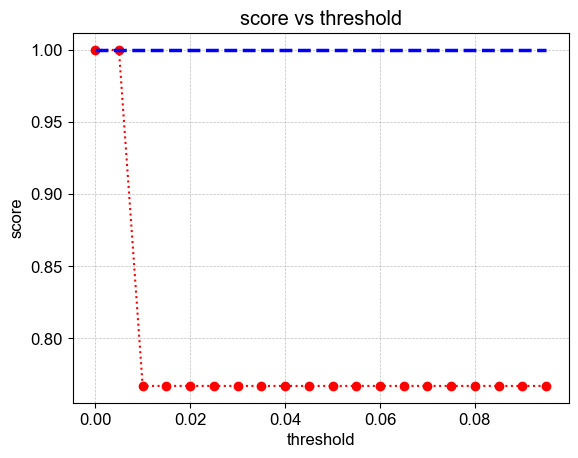

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.831 r + -7.359 r_dot + -3.035 q + -0.063 r_dot^2 q + 0.354 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.439 r + -1.258 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999945661429471
Iteration: 81
[-0.02197837  0.00809804  0.01999779  0.0366129 ]


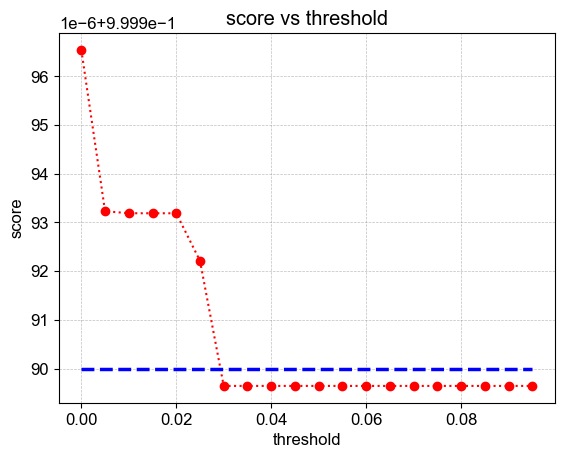

--------------------------------------------------
optimal_threshold: 0.025
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot + -0.013 r_dot^2
(r_dot)' = -337.909 r + -7.360 r_dot + -3.035 q + 0.140 r^2
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922128280049
Iteration: 82
[0.0235515  0.04469764 0.00863362 0.02272954]


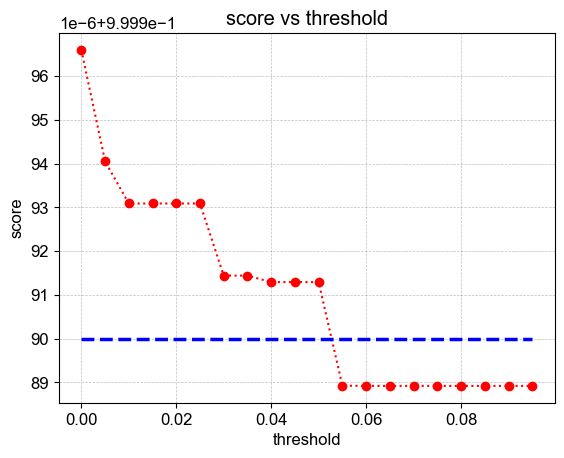

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.941 r + -7.367 r_dot + -3.036 q + -0.107 r^2 + -0.091 r_dot^2 + 0.257 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999912934677401
Iteration: 83
[-0.04100222 -0.0049703   0.00287087 -0.01218217]


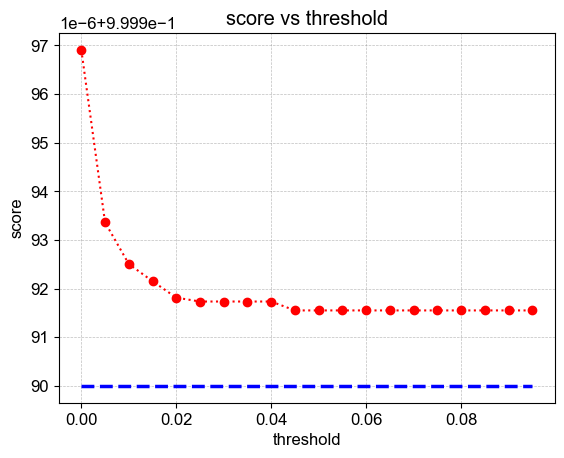

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.112 r + -7.338 r_dot + -3.037 q + 1.106 r^2 + -56.096 r^2 r_dot + 0.742 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915522898774
Iteration: 84
[-0.03972586  0.04274635  0.01031267 -0.04059439]


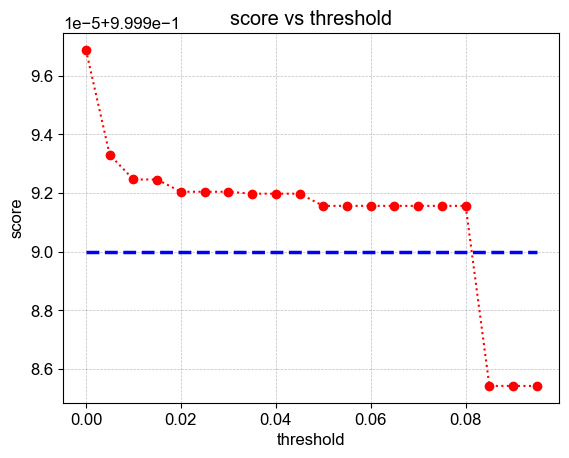

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -337.985 r + -7.331 r_dot + -3.036 q + 0.798 r^2 + -28.326 r^2 r_dot + 0.847 r_dot^2 q + 0.443 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915637036462
Iteration: 85
[-0.02639533  0.03649306 -0.030357    0.00744245]


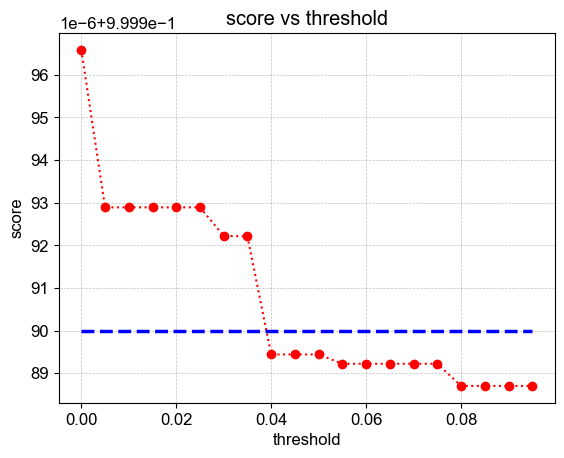

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.108 r + -7.322 r_dot + -3.037 q + 0.236 r^2 + -127.840 r^2 r_dot + 1.187 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922086651947
Iteration: 86
[ 5.29978040e-03  2.44130916e-02  7.89266496e-05 -1.27367254e-02]


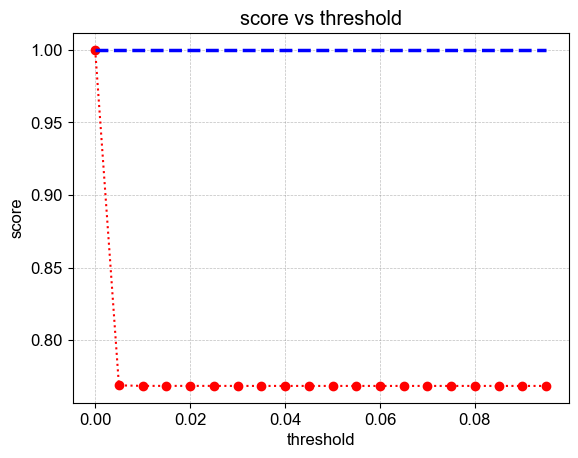

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.026 r + 0.995 r_dot + -0.057 r^2 + -0.008 r_dot^2 + -126.712 r^2 r_dot + -0.029 r^2 q + -2.453 r^2 q_dot + -0.057 r_dot^2 q + 0.001 r_dot^2 q_dot
(r_dot)' = -338.277 r + -7.329 r_dot + -3.039 q + 0.001 q_dot + -3.551 r^2 + -0.472 r_dot^2 + -7949.186 r^2 r_dot + -1.821 r^2 q + -153.885 r^2 q_dot + -3.594 r_dot^2 q + 0.059 r_dot^2 q_dot + 0.007 q^2 q_dot
(q)' = -0.003 r + 1.000 q_dot + -0.001 r^2 + -22.969 r^2 r_dot + 0.074 r^2 q + 0.994 r^2 q_dot + -0.070 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.871 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.254 r^2 + 0.036 r_dot^2 + 577.563 r^2 r_dot + 0.066 r^2 q + 84.660 r^2 q_dot + 3.500 r_dot^2 q + -0.159 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999957972537878
Iteration: 87
[-0.00715244 -0.00290714  0.04997561 -0.00084781]


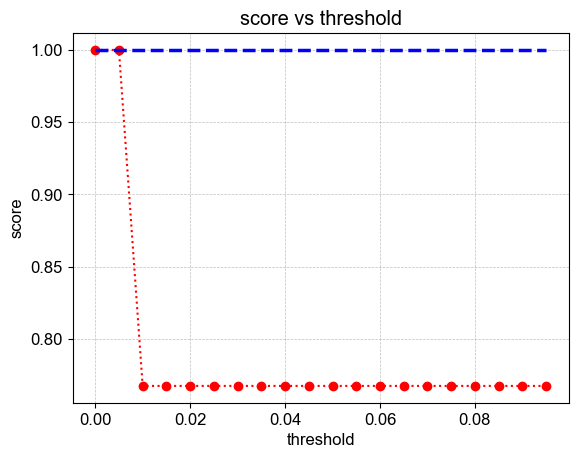

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.927 r + -7.374 r_dot + -3.035 q + 0.007 r^2 + 0.114 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 19.951 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999934662651089
Iteration: 88
[-0.00314904 -0.04235034  0.0242638  -0.0108213 ]


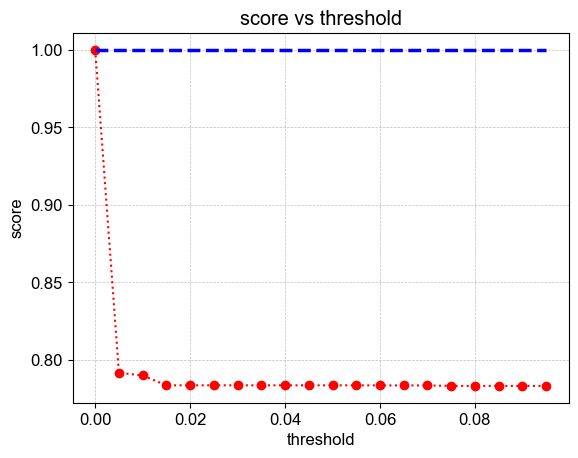

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.044 r + 0.996 r_dot + -0.014 r^2 + -0.008 r_dot^2 + 32.257 r^2 r_dot + 0.007 r^2 q + 0.633 r^2 q_dot + 0.015 r_dot^2 q
(r_dot)' = -337.684 r + -7.369 r_dot + -3.033 q + 2.816 r^2 + 1.592 r_dot^2 + -6259.208 r^2 r_dot + -1.407 r^2 q + -122.714 r^2 q_dot + -2.891 r_dot^2 q + 0.046 r_dot^2 q_dot + 0.005 q^2 q_dot
(q)' = -0.004 r + 0.001 r_dot + 1.000 q_dot + -0.003 r^2 + -125.046 r^2 r_dot + 0.050 r^2 q + -1.183 r^2 q_dot + -0.125 r_dot^2 q
(q_dot)' = 22.827 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.303 r^2 + -0.178 r_dot^2 + 580.390 r^2 r_dot + 0.065 r^2 q + 84.833 r^2 q_dot + 3.507 r_dot^2 q + -0.159 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999954784380478
Iteration: 89
[ 0.02613839  0.03059668  0.02961204 -0.03054093]


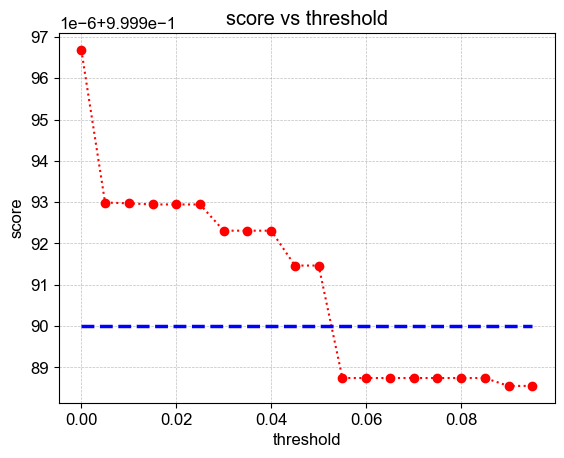

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.941 r + -7.347 r_dot + -3.036 q + -0.171 r^2 + -0.020 r_dot^2 + 0.673 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914633417557
Iteration: 90
[-0.02716765  0.03120553  0.02418083 -0.01374515]


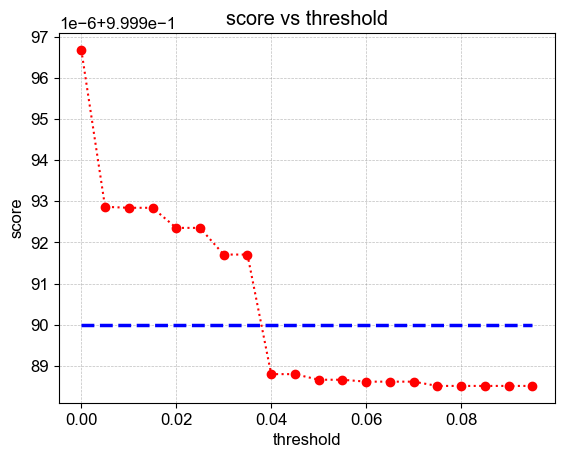

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.027 r + -7.356 r_dot + -3.036 q + 0.230 r^2 + 0.067 r_dot^2 + -76.403 r^2 r_dot + 0.379 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917038232392
Iteration: 91
[-0.03587551  0.04780352  0.03853666 -0.01508107]


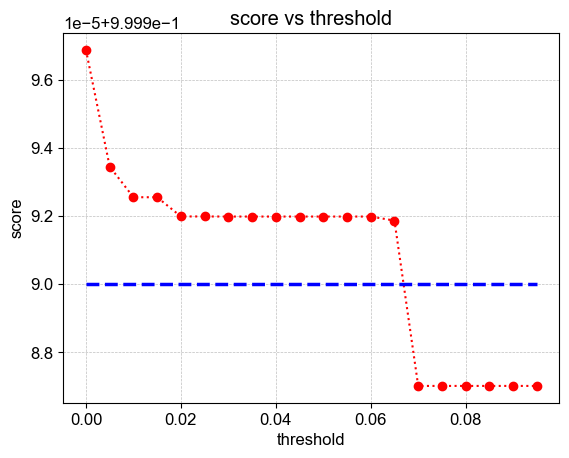

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.061 r + -7.324 r_dot + -3.037 q + 0.572 r^2 + -59.018 r^2 r_dot + 0.944 r_dot^2 q + 1.022 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918680776201
Iteration: 92
[0.00677108 0.02932462 0.00231329 0.00361437]


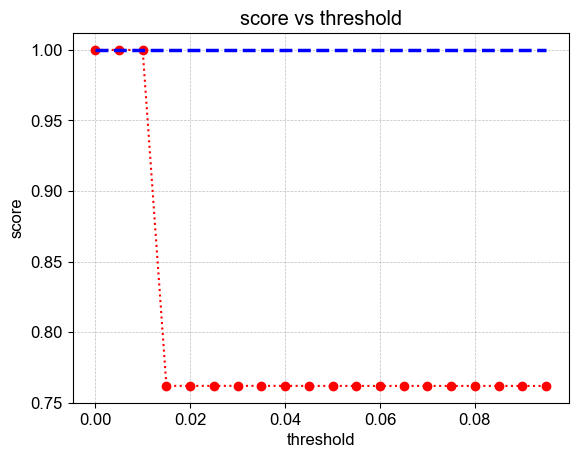

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.946 r + -7.376 r_dot + -3.036 q + -0.238 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.847 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999931118591162
Iteration: 93
[ 0.02366781 -0.00101125  0.01131313  0.02740492]


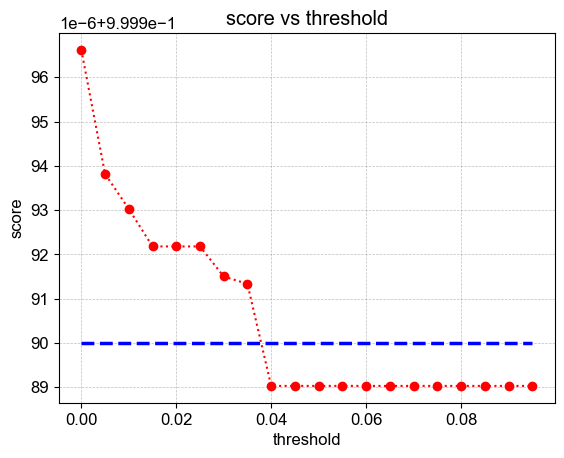

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.916 r + -7.358 r_dot + -3.035 q + -0.179 r^2 + 0.058 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913326967174
Iteration: 94
[-0.04539264  0.02396546 -0.03990186 -0.00660819]


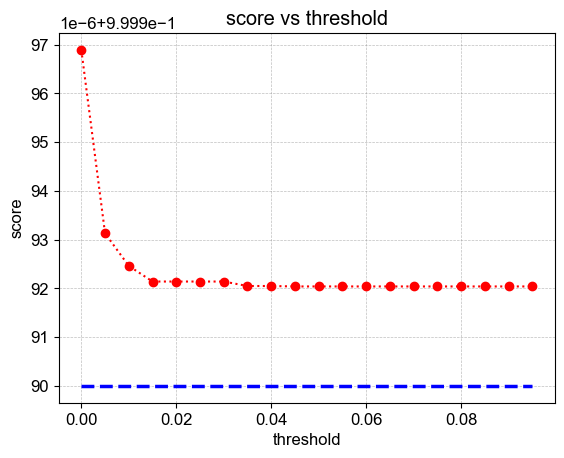

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.222 r + -7.312 r_dot + -3.038 q + 1.179 r^2 + -66.017 r^2 r_dot + -1.127 r_dot^2 q + 1.579 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920404027618
Iteration: 95
[-0.02590358 -0.01456606  0.01572832 -0.04882952]


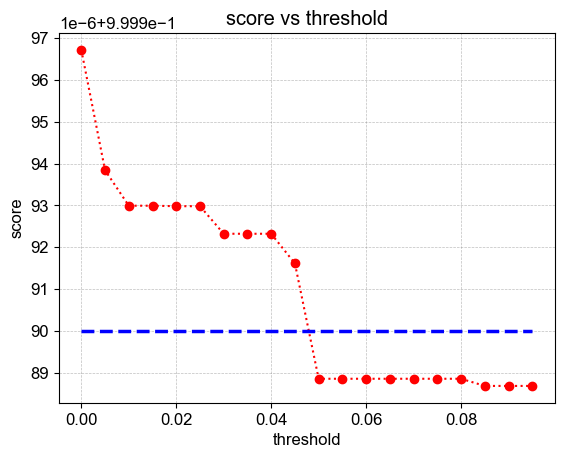

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.930 r + -7.346 r_dot + -3.035 q + 0.135 r^2 + 0.078 r_dot^2 + -0.120 r_dot^2 q + 0.706 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916126102827
Iteration: 96
[-0.0462356  -0.03042391 -0.04754081  0.04242047]


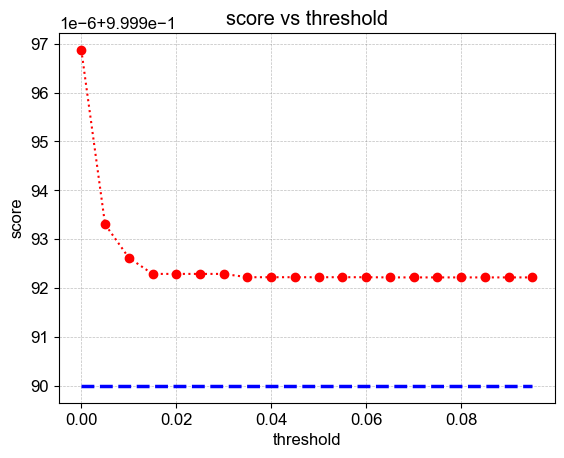

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.334 r + -7.312 r_dot + -3.039 q + 1.295 r^2 + -0.010 r_dot^2 + -90.167 r^2 r_dot + 1.531 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.064 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999922193041921
Iteration: 97
[ 0.0429378   0.03937288 -0.00612201 -0.04537354]


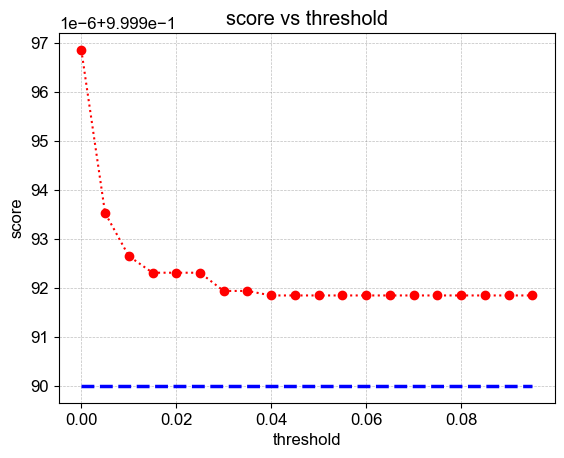

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.245 r + -7.348 r_dot + -3.038 q + -1.103 r^2 + -0.057 r_dot^2 + -84.912 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918463476491
Iteration: 98
[ 0.03507125 -0.0265746   0.03438825  0.02606394]


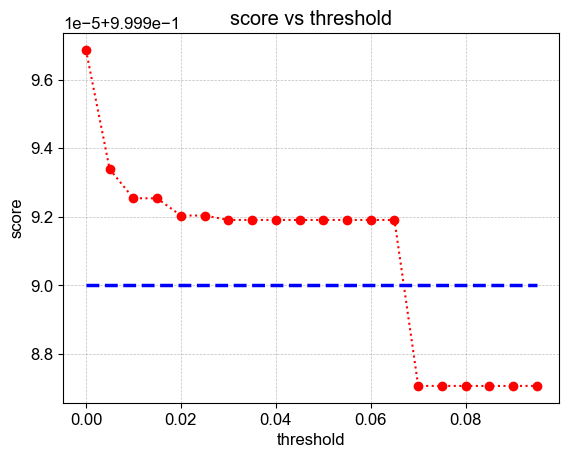

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.175 r + -7.317 r_dot + -3.038 q + -0.573 r^2 + -91.480 r^2 r_dot + -1.381 r_dot^2 q + 1.414 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919084486218
Iteration: 99
[-0.0160888   0.00537028  0.03056529 -0.02877633]


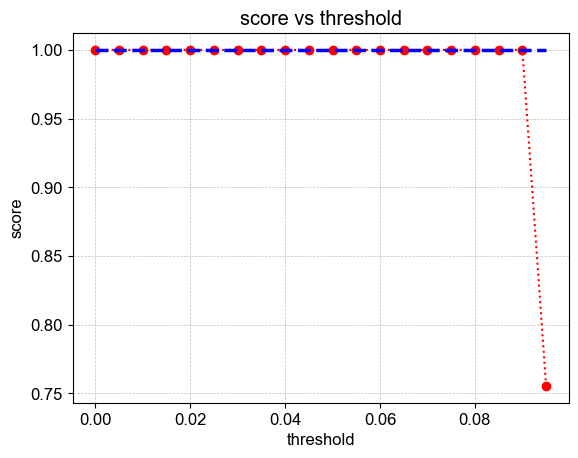

--------------------------------------------------
optimal_threshold: 0.09
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.912 r + -7.366 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.849 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999911591243112


In [153]:
n_initial_conditions = 100

for iter in range(n_initial_conditions):

    print(f'Iteration: {iter}')

     # generate the data for testing
    start = 0
    end = 100
    step = 0.01
    n_points = int((end-start)/step)
    t_span = [start, end]

    # generate random initial condition between -2 and 2
    x0 = np.random.rand(4) * 0.1 - 0.05
    print(x0)

    sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
    t = np.arange(start, end+step/10, step)
    x = sol.sol(t).T

    # The feature names of the columns of y
    feature_names = ['r', 'r_dot', 'q', 'q_dot']

    functions = [lambda x : x,
                lambda x: x ** 2,
                lambda x,y: x ** 2 * y
                ]

    function_names = [lambda x : str(x), 
                    lambda x: str(x) + "^2",
                    lambda x,y: str(x) + "^2 " + str(y)
                    ]


    lib_custom = CustomLibrary(library_functions=functions, 
                            function_names=function_names)
    lib_custom.fit(x)
    lib_custom.transform(x)

    feature_library = lib_custom


    feature_library.fit(x)

    # Differentiation method
    differentiation_method = ps.FiniteDifference(order=2)

    scores = []

    threshold_start = 0
    threshold_end = 0.1
    threshold_step = 0.005

    thresholds = np.arange(threshold_start, threshold_end, threshold_step)

    for threshold in thresholds:
        opt = ps.STLSQ(threshold=threshold)
        model=ps.SINDy(differentiation_method=differentiation_method,
                    feature_library = feature_library,
                    feature_names=feature_names, 
                    optimizer=opt)
        model.fit(x,t=t)
        scores.append(model.score(x,t=t))

    score_threshold = 0.99999
    threshold_line = np.ones(thresholds.shape) * score_threshold

    plt.plot(thresholds, scores, 'ro:')
    plt.plot(thresholds, threshold_line, 'b--', linewidth=2.5)
    plt.xlabel('threshold')
    plt.ylabel('score')
    plt.yscale('linear')
    plt.title('score vs threshold')
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()



    optimal_threshold = None
    for i in range(len(scores)):
        if scores[i] > score_threshold:
            optimal_threshold = thresholds[i]
        else:
            break

    print('-'*50)
    print(f'optimal_threshold: {optimal_threshold}')
    print('-'*50)


    # optimal_threshold = 0.015 # for testing

    if optimal_threshold is None:
        raise ValueError('No threshold found that gives a score > score_threshold')
    else:
        opt = ps.STLSQ(
            threshold=optimal_threshold
            )
        model=ps.SINDy(differentiation_method=differentiation_method,
                        feature_library=feature_library,
                        feature_names=feature_names,
                        optimizer=opt)
        model.fit(x,t=t)
        print('Identified model:')
        model.print()

        print('Score on training data:')
        print(model.score(x,t=t))

    coefficients = model.coefficients()

    if iter == 0:
        z = np.array(coefficients)
    else:    
        z = np.vstack((z, coefficients))

In [154]:
z = z.reshape(n_initial_conditions,4,14)
z[5,:,:]

array([[ 0.00000000e+00,  9.95799482e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-3.38245695e+02, -7.34576887e+00, -3.03838092e+00,
         0.00000000e+00,  1.28772016e+00,  5.90982853e-02,
         0.00000000e+00,  0.00000000e+00, -8.27159135e+01,
         0.00000000e+00,  0.00000000e+00,  7.72360161e-01,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         9.99974962e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 2.28454124e+01,  4.96109892e-01, -1.22707976e+00,
         2.87142477e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.

In [162]:
# getting the feature names
for idx, name in enumerate(model.get_feature_names()):
    print(f"{idx+1} : {name}")


# find the mean of the coefficients
mean = z.mean(axis=0)
# find the standard deviation of the coefficients
std = z.std(axis=0)
# create the zeroing criteria. If the standard deviation is greater than the mean, then zero out the coefficient
zeroing_criteria = np.abs(std)/np.abs(mean)

# zero out the terms with a large standard deviation
mean[zeroing_criteria>1] = 0

#print the mean and standard deviation

print("mean: ")
print(mean)

print("std: ")
print(std)

print('zeroing_criteria: ')
print(zeroing_criteria)


1 : r
2 : r_dot
3 : q
4 : q_dot
5 : r^2
6 : r_dot^2
7 : q^2
8 : q_dot^2
9 : r^2 r_dot
10 : r^2 q
11 : r^2 q_dot
12 : r_dot^2 q
13 : r_dot^2 q_dot
14 : q^2 q_dot
mean: 
[[ 0.00000000e+00  9.97106920e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.38048697e+02 -7.34322965e+00 -3.03654755e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.99975354e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.21986293e+01  3.86867057e-01 -1.23294077e+00  2.86299197e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 

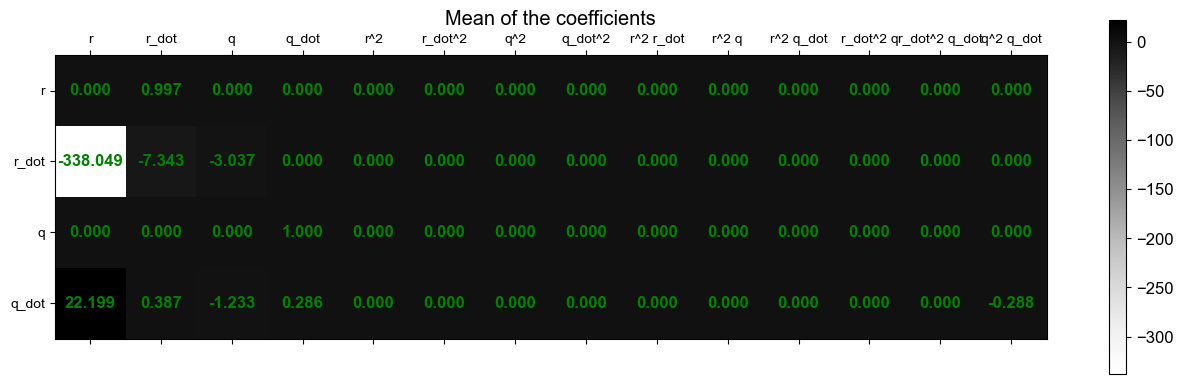

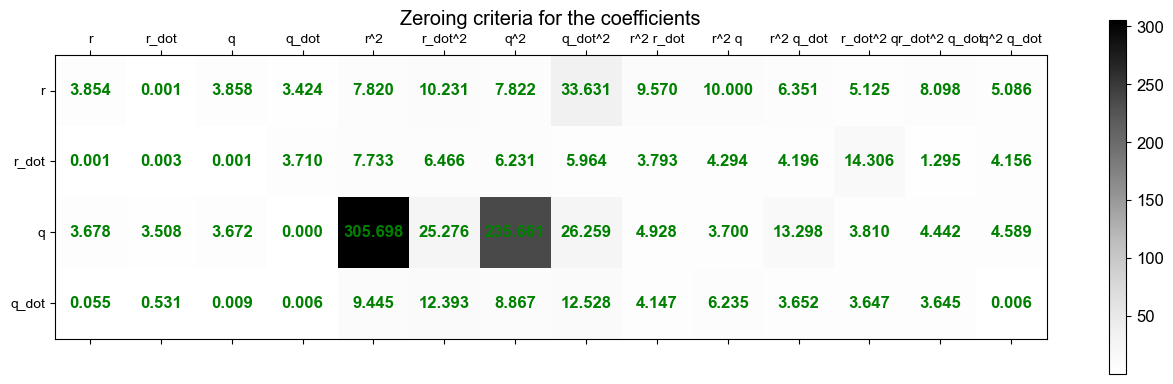

In [171]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

xticklabels = model.get_feature_names()
yticklabels = feature_names


plt.matshow(mean, cmap='Greys')
for i in range(mean.shape[0]):
    for j in range(mean.shape[1]):
        plt.annotate("{:.3f}".format(mean[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(mean.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(mean.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Mean of the coefficients")
plt.savefig(directory + '/' + "mean.pdf", dpi=300)
plt.colorbar()
plt.show()


plt.matshow(zeroing_criteria, cmap='Greys')
for i in range(zeroing_criteria.shape[0]):
    for j in range(zeroing_criteria.shape[1]):
        plt.annotate("{:.3f}".format(zeroing_criteria[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(zeroing_criteria.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(zeroing_criteria.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Zeroing criteria for the coefficients")
plt.savefig(directory + '/' + "zeroing_criteria.pdf", dpi=300)
plt.colorbar()
plt.show()

In [48]:
model.get_feature_names()

['r',
 'r_dot',
 'q',
 'q_dot',
 'r^2',
 'r_dot^2',
 'q^2',
 'q_dot^2',
 'r^2 r_dot',
 'r^2 q',
 'r^2 q_dot',
 'r_dot^2 q',
 'r_dot^2 q_dot',
 'q^2 q_dot']

In [184]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 0.1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

def id_sys(t, x):
    xdot = np.zeros_like(x)
    xdot[0] = 0.997 * x[1]
    xdot[1] = -338.049 * x[0] -7.343 * x[1] - 3.037 * x[2] 
    xdot[2] = x[3]
    xdot[3] = 22.199 * x[0] + 0.387 * x[1] - 1.233 * x[2] +0.286 * x[3] - 0.288 * (x[2]**2) * x[3]
    return xdot


# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]

# generate random initial condition between -2 and 2
x0 = np.random.rand(4) * 0.1 -  0.05
print(x0)

sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
t = np.arange(start, end+step/10, step)
x_true = sol.sol(t).T

sol = solve_ivp(id_sys, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
x_id = sol.sol(t).T  

# plt.plot(t,x_true[:,0])
# plt.plot(t,x_id[:,0])
# plt.show()

[-0.00847676  0.02659213 -0.03907292  0.0094244 ]


In [185]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

In [3]:
# plot the solution

plt.rcdefaults()
plt.rcParams.update({'font.size': 12})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# x1
plot_comparison(t, x_true[:,0], x_id[:,0], "t", "r", "r", directory=directory)

# x2
plot_comparison(t, x_true[:,2], x_id[:,2], "t", "q", "q",directory=directory)

# x1 dot
plot_comparison(t, x_true[:,1], x_id[:,1], "t", "\dot{r}", "rdot", directory=directory)

# x2 dot
plot_comparison(t, x_true[:,3], x_id[:,3], "t", "\dot{q}", "qdot", directory=directory)

NameError: name 't' is not defined

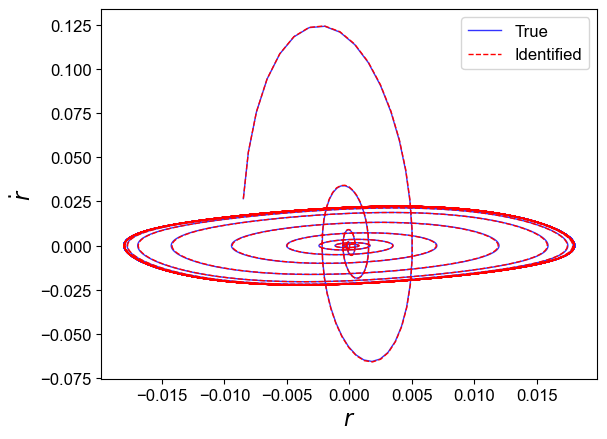

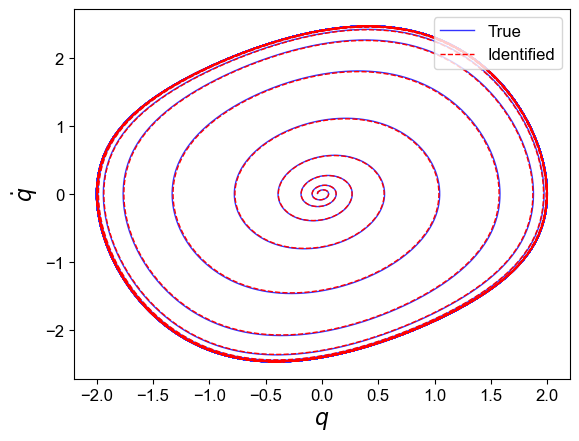

In [187]:
# Phase Portrait Oscillator 1
plot_pp(x_true[:,0], x_true[:,1], x_id[:,0], x_id[:,1], "r", "\dot{r}", "pp_r", directory=directory)

# Phase Portrait Oscillator 2
plot_pp(x_true[:,2], x_true[:,3], x_id[:,2], x_id[:,3], "q", "\dot{q}", "pp_q", directory=directory)

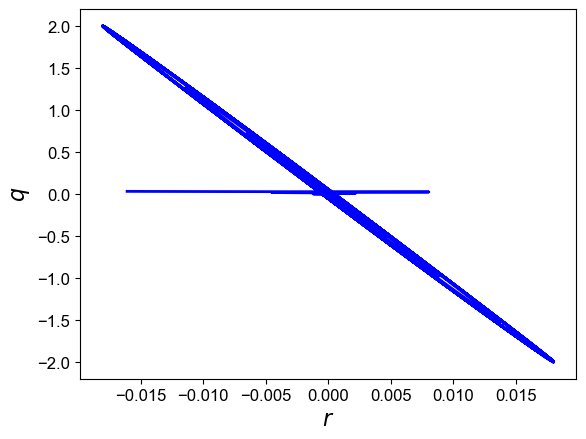

In [188]:
# Displacement Lissajous Figure
plot_lissajous(x[:,0], x[:,2], "r", "q", "lissajous_disp", directory=directory)

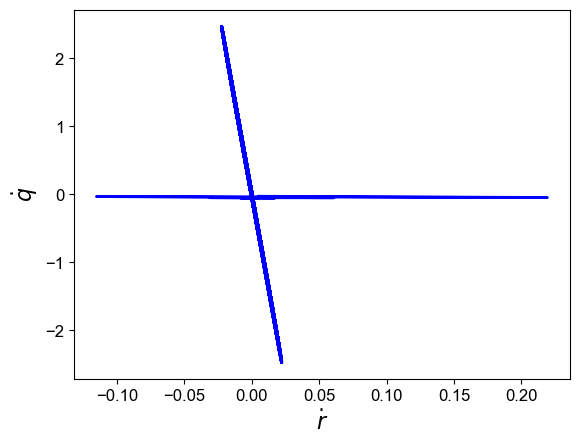

In [189]:
# Velocity Lissajous Figure
plot_lissajous(x[:,1], x[:,3], "\dot{r}", "\dot{q}", "lissajous_vel", directory=directory)